# Analisi esperimenti numerici

Un piccolo notebook per analizzare i dati degli esperimenti numerici, che salvo in un file `.csv`

## Imports, creazione del dataframe

In [1]:
%reload_ext autoreload
%autoreload 2

In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from decimal import Decimal

from utilities import *
import optperfprofpy    

In [ ]:
CSV_FILENAME = "bench-v0.1.5alpha-04_06-mpmath_ref.csv"
CSV_DELTA_FILENAME = "delta-bench-v0.1.5alpha-04_07.csv"

In [4]:
df = pd.read_csv(CSV_FILENAME)
df_delta = pd.read_csv(CSV_DELTA_FILENAME)

In [5]:
print(f"df.shape = {df.shape},\t df_delta.shape = {df_delta.shape}")

df.shape = (2670, 26),	 df_delta.shape = (2526, 17)


In [6]:
# n° of scaling_and_squaring samples + df_delta.shape[0] = df_shape
df[df["approximant"]=="scaling_and_squaring"].shape[0] + df_delta.shape[0]

2670

***OSS***: Il `df_delta` è più piccolo perché non è stato eseguito lo scaling and squaring standard di Julia. Infatti esso non serve a niente, per l'analisi del $\delta$.

In [7]:
df.head()

,kind,n,eltype,ishermitian,approximant,algorithm,schur_time,alpha_time,eval_bound_time,eval_pade_time,...,cond_q,epsilon,rel_err_F,abs_err_1,nrm1_Ytrue,Ytrue_method,cond_expA_F,condA_1,condA_2,precision
0,rand_8,8,Float64,False,scaling_and_squaring,NaN,NaN,NaN,NaN,NaN,...,NaN,2.220446e-16,2.373560e-16,1.802861592277032e-14,80.90624298686493,mpmath_1792,4.871499,416.710942,183.633838,53
1,rand_8,8,Float64,False,diagonalcheap,transfree,0.000000,0.000091,2.815232,0.876207,...,23.980249,2.220446e-16,8.831571e-16,7.031690783208075e-14,80.90624298686493,mpmath_1792,4.871499,416.710942,183.633838,53
2,rand_8,8,Float64,False,diagonalcheap,transfree,0.000000,0.000442,0.023291,0.001627,...,22.670589,1.727234e-77,2.966314e-77,2.17128735881013e-75,80.90624298686493,mpmath_1792,4.871499,416.710942,183.633838,256
3,rand_8,8,Float64,False,diagonalcheap,transfree,0.000000,0.001708,0.023066,0.004973,...,22.275739,1.331998e-256,3.663965e-256,2.73813523479176e-254,80.90624298686493,mpmath_1792,4.871499,416.710942,183.633838,851
4,rand_8,8,Float64,False,diagonalcheap,complexschur,0.005105,0.000195,3.271237,0.852246,...,13.821267,2.220446e-16,1.374308e-15,1.278113663697772e-13,80.90624298686493,mpmath_1792,4.871499,416.710942,183.633838,53


Qualche utile costante:

In [8]:
COLS = ["kind", "n", "approximant", "algorithm", "rel_err_F", "cond_expA_F", "epsilon", "precision"]
WRK_PRECS = df["precision"].unique()

## Descrizione (e aggiustamento) colonne

In [9]:
df.columns

Index(['kind', 'n', 'eltype', 'ishermitian', 'approximant', 'algorithm',
       'schur_time', 'alpha_time', 'eval_bound_time', 'eval_pade_time',
       'squaring_time', 'total_time', 'm', 's', 'delta', 'psi', 'cond_q',
       'epsilon', 'rel_err_F', 'abs_err_1', 'nrm1_Ytrue', 'Ytrue_method',
       'cond_expA_F', 'condA_1', 'condA_2', 'precision'],
      dtype='object')

Ecco una descrizione delle colonne di `df`:
- `kind`: un identificativo del "tipo" di matrice che ha prodotto i risultati della riga corrispondente
- `n`: dimensione della matrice 
- `eltype`: tipo degli elementi della matrice
- `ishermitian`: se la matrice è Hermitiana o meno 
- `approximant`: approssimante scelta per il calcolo dell'esponenziale di matrice 
- `algorithm`: algoritmo usato da `exp_mp`. Può essere Schur reale, Schur complesso o niente Schur
- `schur_time`: tempo impiegato per calcolare la forma di Schur
- `alpha_time`: tempo totale impiegato per valutare l'$\alpha_{\min}$ in `exp_mp`
- `eval_bound_time`: tempo totale impiegato per valutare il bound sull'errore in `exp_mp`. Si osservi che la valutazione del bound può formare nuove potenze di $A$
- `eval_pade_time`: tempo totale impiegato nel valutare l'approssimante 
- `squaring_time`: tempo speso nella fase di squaring
- `total_time`: tempo totale impiegato dall'algoritmo (viene misurato direttamente. Non è la somma dei tempi precedenti)
- `m`: grado dell'approssimante scelto dall'algoritmo `exp_mp`
- `s`: fattore di scaling scelto dall'algoritmo `exp_mp` ($A$ viene scalata di $2^{-s}$)
- `delta`: valore finale di $\delta$ (ossia upper bound sull'errore) prodotto in `exp_mp`
- `psi`: valore finale di $\psi$ (ossia, stima di $\exp(A)$ usata stimare per l'errore relativo durante l'esecuzione di `exp_mp`)
- `cond_q`: valore finale del numero di condizionamento (in norma 1) di $q_m(2^{-s}A)$
- `epsilon`: valore $\epsilon$ usato per la tolleranza sull'errore relativo. Può essere passato in input, il valore di default è la precisione di macchina della precisione usata all'interno dell'algoritmo
- `rel_err_F`: accuratezza relativa della soluzione calcolata, in norma di Frobenius
- `abs_err_1`: errore assoluto della soluzione calcolata, in norma 1
- `nrm1_Ytrue`: norma 1 della soluzione di riferimento $Y_{\textup{true}}$ (considerata esatta nella valutazione dell'errore relativo)
- `Ytrue_method`: metodo usato per costruire $Y_{\textup{true}}$. La soluzione esatta può essere stata fornita insieme all'input $A$, o altrimenti può essere stata costruita per diagonalizzazione o eseguendo `exp_mp` in precisione più alta
- `cond_expA_F`: $\kappa_{\exp}(A)$, numero di condizionamento dell'esponenziale di $A$, in norma di Frobenius (se $A$ è troppo grande, il valore è `NaN`. Infatti il calcolo è "esatto")
- `condA_1`: $\kappa_1(A)$, numero di condizionamento di $A$ in norma 1
- `condA_2`: $\kappa_2(A)$, numero di condizionamento di $A$ in norma 2
- `precision`: il valore di precisione usato all'interno dell'algoritmo. Esso determina il valore della precisione di macchina $u$

In [10]:
df.dtypes

kind                object
n                    int64
eltype              object
ishermitian           bool
approximant         object
algorithm           object
schur_time         float64
alpha_time         float64
eval_bound_time    float64
eval_pade_time     float64
squaring_time      float64
total_time         float64
m                  float64
s                  float64
delta              float64
psi                float64
cond_q             float64
epsilon            float64
rel_err_F          float64
abs_err_1           object
nrm1_Ytrue          object
Ytrue_method        object
cond_expA_F        float64
condA_1            float64
condA_2            float64
precision            int64
dtype: object

Passiamo a guardare `df_delta`

In [11]:
df_delta.columns

Index(['kind', 'n', 'eltype', 'ishermitian', 'approximant', 'algorithm', 'm',
       's', 'delta', 'psi', 'cond_q', 'epsilon', 'rel_err_F', 'abs_err_1',
       'nrm1_Yb4Sq_true', 'Ytrue_method', 'precision'],
      dtype='object')

Qui ci sono molte meno colonne. Sono essenzialmente le stesse di `df`, anzi, qualcuna in meno. Soltanto tre sono veramente da spiegare:
- `rel_err_F`: l'errore relativo, in norma di Frobenius, tra l'approssimazione calcolata dall'algoritmo *prima dello squaring* e il suo esponenziale "esatto". In formule, $$\lvert\lvert \exp(2^{-s}A) - r_m(2^{-s}A)\rvert\rvert_F/\lvert\lvert\exp(2^{-s}A)\rvert\rvert_F$$ dove $s$ e $m$ sono i parametri selezionati da $\mathtt{exp\_mp}$ e l'esponenziale è calcolato con $\mathtt{mpmath}$
- `abs_err_1`: L'errore assoluto, in norma 1, tra l'approssimazione calcolata da $\mathtt{exp\_mp}$ *prima dello squaring* e il suo esponenziale "esatto". In formule, $\lvert\lvert\exp(2^{-s}A)-r_m(2^{-s}A)\rvert\rvert_1$ (stesse convenzioni di prima)
- `nrm1_Yb4Sq_true`: La norma 1 dell'esponenziale di $2^{-s}A$, dove $s$ è il parametro di scaling scelto da $\mathtt{exp\_mp}$.

Nella sezione "$\delta" è un upper bound?" spiegheremo un po'

In [12]:
df_delta.dtypes

kind                object
n                    int64
eltype              object
ishermitian           bool
approximant         object
algorithm           object
m                  float64
s                  float64
delta              float64
psi                float64
cond_q             float64
epsilon            float64
rel_err_F          float64
abs_err_1           object
nrm1_Yb4Sq_true     object
Ytrue_method        object
precision            int64
dtype: object

Adesso applichiamo trasformazioni utili

In [13]:
for colname in ["abs_err_1", "nrm1_Ytrue"]:
    if df[colname].dropna().map(type).eq(str).all():
        df[colname] = df[colname].map(Decimal)

for colname in ["abs_err_1", "nrm1_Yb4Sq_true"]:
    if df_delta[colname].dropna().map(type).eq(str).all():
        df_delta[colname] = df_delta[colname].map(Decimal)

## Analisi

In [14]:
df.columns

Index(['kind', 'n', 'eltype', 'ishermitian', 'approximant', 'algorithm',
       'schur_time', 'alpha_time', 'eval_bound_time', 'eval_pade_time',
       'squaring_time', 'total_time', 'm', 's', 'delta', 'psi', 'cond_q',
       'epsilon', 'rel_err_F', 'abs_err_1', 'nrm1_Ytrue', 'Ytrue_method',
       'cond_expA_F', 'condA_1', 'condA_2', 'precision'],
      dtype='object')

### Quante sono Hermitiane?

In [15]:
hermitian_samples_counts  = df["ishermitian"].value_counts()
hermitian_samples_perctgs = (100 * hermitian_samples_counts / len(df)).round(2)

pd.DataFrame({
    "Count" : hermitian_samples_counts,
    "Percentage" : hermitian_samples_perctgs
})

,Count,Percentage
ishermitian,,
False,1967,73.67
True,703,26.33


Ok, ma vediamo le *matrici*...

In [16]:
grouped_by_kind = df.groupby(["kind", "n"])

hermitian_kind_counts  = grouped_by_kind["ishermitian"].agg("unique").value_counts()
hermitian_kind_perctgs = (100 * hermitian_kind_counts / len(grouped_by_kind)).round(2)

pd.DataFrame({
    "Count" : hermitian_kind_counts,
    "Percentage" : hermitian_kind_perctgs
})

,Count,Percentage
ishermitian,,
[False],107,74.31
[True],37,25.69


### Com'è stata ottenuta $Y_{\textup{true}}$?

In [17]:
ytrue_samples_counts  = df['Ytrue_method'].value_counts()
ytrue_samples_perctgs = (100 * ytrue_samples_counts / df.shape[0]).round(2)

pd.DataFrame({
    'Count': ytrue_samples_counts,
    'Percentage': ytrue_samples_perctgs
})

,Count,Percentage
Ytrue_method,,
mpmath_1792,2518,94.31
given,152,5.69


Ok ma vediamo le *matrici*...

In [18]:
grouped_by_kind = df.groupby(["kind", "n"])

ytrue_kind_counts  = grouped_by_kind["Ytrue_method"].agg("unique").value_counts()
ytrue_kind_perctgs = (100 * ytrue_kind_counts / len(grouped_by_kind)).round(2)

pd.DataFrame({
    'Count': ytrue_kind_counts,
    'Percentage': ytrue_kind_perctgs
})

,Count,Percentage
Ytrue_method,,
[mpmath_1792],136,94.44
[given],8,5.56


### Taglie `n` delle matrici

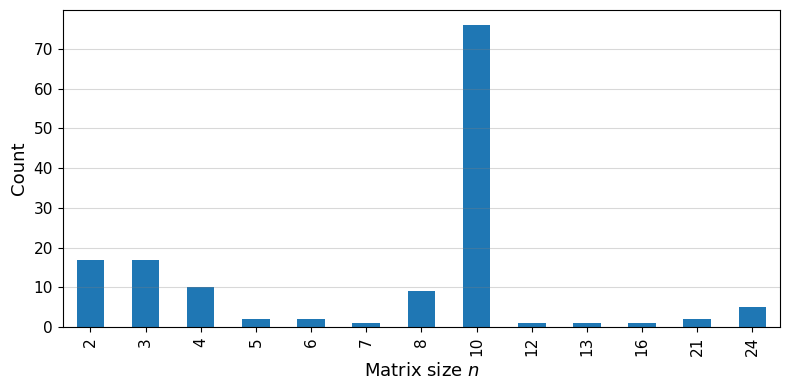

In [19]:
vc = df.drop_duplicates(subset=["kind","n"])["n"].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(8,4))
vc.plot(kind='bar', ax=ax)

# # add counts on top of bars
# for p in ax.patches:
#     ax.annotate(str(int(p.get_height())), 
#                 (p.get_x() + p.get_width() / 2, p.get_height()),
#                 ha='center', va='bottom', fontsize=9)

ax.set_xlabel(r'Matrix size $n$', fontsize=13)
ax.set_ylabel('Count', fontsize=13)
#ax.set_title('Number of distinct matrices per matrix size', fontsize=14, fontweight="bold")
ax.tick_params(axis='both', labelsize=11)
ax.grid(axis='y', color='gray', alpha=0.3)

plt.tight_layout()
plt.show()

### $\delta$ è un upper bound?

Prima di tutto, concentriamoci su dove $\delta$ c'è. Ovvero, guardiamo a dove l'algoritmo è `exp_mp` e non lo scaling e squaring standard.

In [20]:
df.loc[df["approximant"] == "scaling_and_squaring", "delta"].unique()

array([nan])

In [21]:
print("In the original dataframe:")
print(f"\tThere are {sum(df["delta"].isna())} samples with delta = NaN ({100 * sum(df["delta"].isna() / df.shape[0]):2.2f}% of the total)")
print(f"\tThere are {sum(df["delta"]==0)} samples with delta = 0   ({100 * sum(df["delta"]==0) / df.shape[0]:2.2f}% of the total)")
print()

print("In the delta dataframe: ")
print(f"\tThere are {sum(df_delta["delta"].isna())} samples with delta = NaN ({100 * sum(df_delta["delta"].isna() / df_delta.shape[0]):2.2f}% of the total)")
print(f"\tThere are {sum(df_delta["delta"]==0)} samples with delta = 0   ({100 * sum(df_delta["delta"]==0) / df_delta.shape[0]:2.2f}% of the total)")


In the original dataframe:
	There are 490 samples with delta = NaN (18.35% of the total)
	There are 309 samples with delta = 0   (11.57% of the total)

In the delta dataframe: 
	There are 346 samples with delta = NaN (13.70% of the total)
	There are 194 samples with delta = 0   (7.68% of the total)


**IMPORTANTE**: Per questa analisi useremo il `df_delta`. Questo dataframe è stato ottenuto in una run successiva rispetto a quella che ha prodotto i dati in `df`. Ma l'algoritmo è lo stesso. Più avanti spiegheremo un po'

I $\delta = \mathtt{NaN}$ possono anche essere dovuti al fatto che $A$ è Hermitiana. In questo caso infatti l'algoritmo diagonalizza, e i parametri ~~$m,s$~~, $\psi,\delta,\kappa_A$ sono `NaN`.

Per fare l'analisi su $\delta$, queste righe le togliamo. Inoltre, teniamo traccia di dove $\delta$ è uguale a $0$. 

Facciamo di più: escludiamo direttamente i samples relativi a matrici Hermitiane. Per il calcolo del loro esponenziale non si fa scaling and squaring, si diagonalizza direttamente, $\delta$ non interviene proprio

In [22]:
# Escludiamo i samples relativi a matrici Hermitiane
df_delta = df_delta[~df_delta["ishermitian"]]

In [23]:
print("In the delta dataframe, after excluding Hermitian matrices: ")
print(f"\tThere are {sum(df_delta["delta"].isna())} samples with delta = NaN ({100 * sum(df_delta["delta"].isna() / df_delta.shape[0]):2.2f}% of the total)")
print(f"\tThere are {sum(df_delta["delta"]==0)} samples with delta = 0   ({100 * sum(df_delta["delta"]==0) / df_delta.shape[0]:2.2f}% of the total)")


In the delta dataframe, after excluding Hermitian matrices: 
	There are 28 samples with delta = NaN (1.51% of the total)
	There are 188 samples with delta = 0   (10.11% of the total)


In [24]:
delta_present   = df_delta["delta"].dropna().index  # togliamo le righe dove delta è NaN
delta_is_0_idxs = df_delta[df_delta["delta"]==0].index

df_delta = df_delta.loc[delta_present]
df_delta.shape

(1832, 17)

La formula (3.14) di [hf19_mpexpm] legge:
$$
    \lvert\lvert\exp(X) - r_m(X)\rvert\rvert \le \lvert\lvert q_m(X)^{-1}\rvert\rvert\,\left\vert q_m(\alpha_d(X)e^{\alpha_d(X)}-p_m(\alpha_d(X))\right\vert\coloneqq\delta
$$


La domanda più pressante che mi viene in mente è: ma alla fine, $\delta$ è un upper bound all'errore, come rivendicano gli autori dell'articolo? 

***OSS***: Consideriamo che per il calcolo di un termine di $\delta$ si usa una stima della norma 1 eh...

**IMPORTANTE**: La matrice $X$ è $2^{-s}A$. Il $\delta$ viene calcolato *prima* dello squaring. La formula qui in alto è un upper bound sull'errore di troncamento nell'approssimazione di $\exp(2^{-s}A)$ con $r_m(2^{-s}A)$, in altri termini $\delta$ dà una limitazione all'errore di troncamento *prima dello scaling*.

Il $\delta$ restituito dall'algoritmo "ha al suo interno lo scaling". Non ha senso confrontarlo con il valore `abs_err_1` di `df`, perché quest'ultimo misura $\lvert\lvert\exp(A) - r_m(A)\rvert\rvert_1$: è un altro errore.

Il valore `abs_err_1` di `df_delta` è quello dell'errore assoluto giusto: $\lvert\lvert\exp(2^{-s}A)- r_m(2^{-s}A)\rvert\rvert_1$, dove $s$ è il valore del parametro di scaling all'uscita di $\mathtt{exp\_mp}$

In [25]:
delta_is_upper_bound_to_abserr = df_delta["abs_err_1"] <= df_delta["delta"]
d_is_ub_to_abserr_and_d_ne0 = df_delta.loc[~df_delta.index.isin(delta_is_0_idxs), "abs_err_1"] \
                                <= df_delta.loc[~df_delta.index.isin(delta_is_0_idxs), "delta"]

print(f"abs_err <= delta in {sum(delta_is_upper_bound_to_abserr)} out of {df_delta.shape[0]} samples")
print(f"Excluding those for which delta = 0, abs_err <= delta in {sum(d_is_ub_to_abserr_and_d_ne0)} out of {df_delta[~df_delta.index.isin(delta_is_0_idxs)].shape[0]} samples")
print(f"abs_err = delta = 0 in {df_delta[df_delta.index.isin(delta_is_0_idxs) & (df_delta["abs_err_1"] == 0)].shape[0]} samples")

abs_err <= delta in 71 out of 1832 samples
Excluding those for which delta = 0, abs_err <= delta in 26 out of 1644 samples
abs_err = delta = 0 in 45 samples


In [64]:
sum(df_delta["delta"]==0)

188

In [26]:
# teniamo un dataframe in cui sono esclusi i samples con delta == 0, 
# perché la divisione dà problemi 
df_delta_delne0 = df_delta[~df_delta.index.isin(delta_is_0_idxs)]

Iniziamo confrontando direttamente `delta` con gli errori, dividendo per precisione. 

I plots nella colonna a sinistra mettono a confronto `delta` con l'errore assoluto `abs_err_1`. I datapoints corrispondenti `delta` dovrebbero stare tutti "sopra" a quelli che corrispondono a `abs_err_1`.

I plots nella colonna a destra confrontano `delta / psi` con l'errore relativo `abs_err_1 / nrm_Y4bSq_true`. Questi plots sono meno significativi, perché non ci sono garanzie teoriche, dato che $\psi$ non è un lower bound per $\exp(2^{-s}A)$

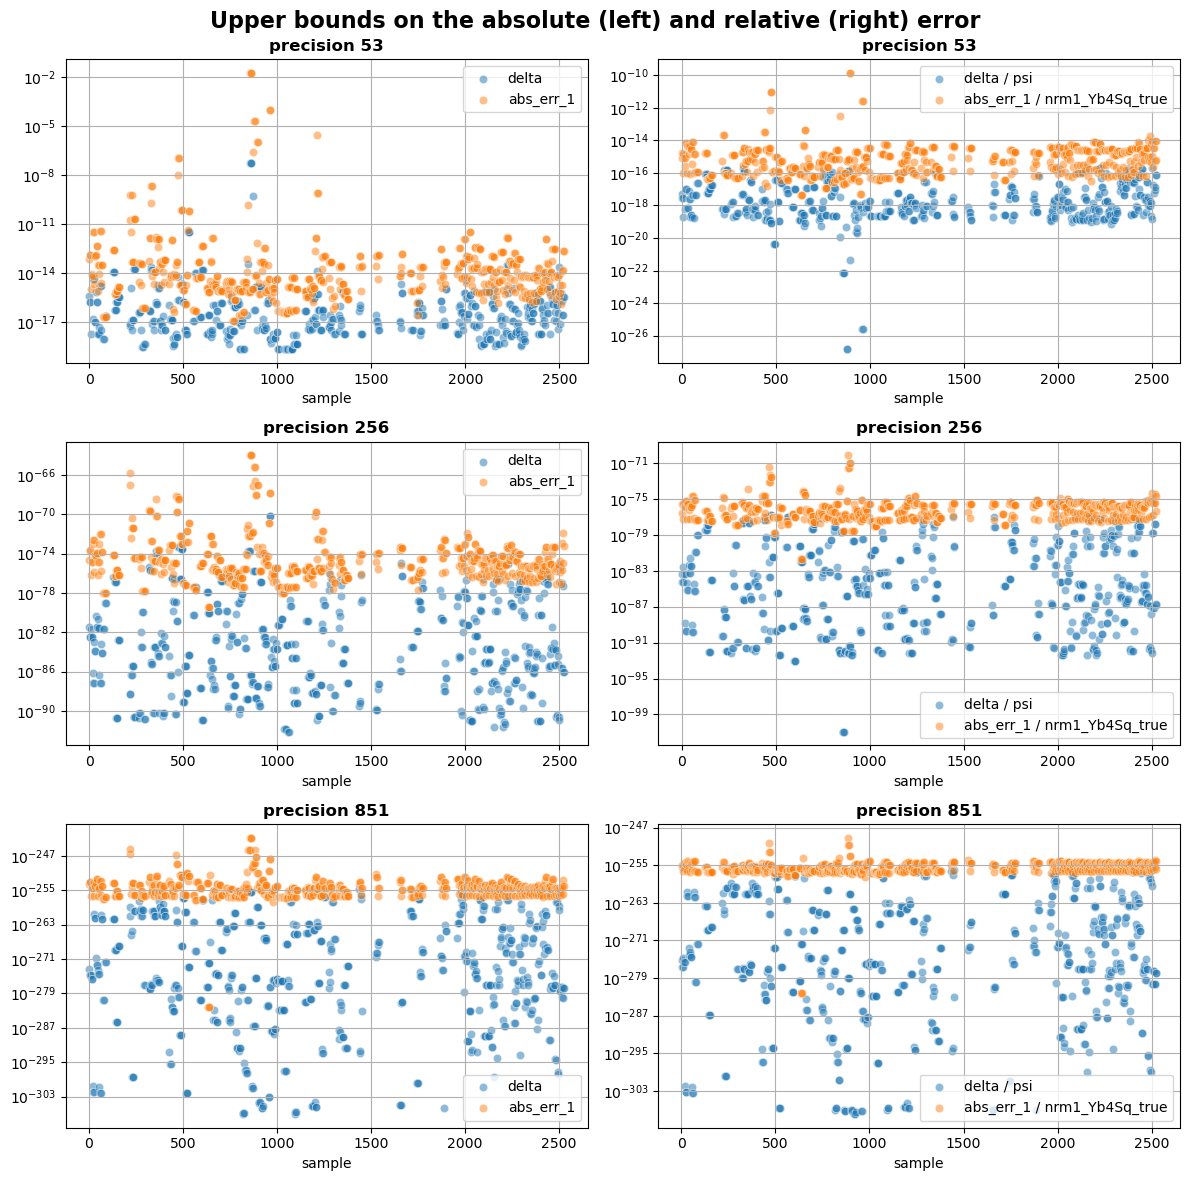

In [43]:
fig, axs = plt.subplots(len(WRK_PRECS),2, figsize=(4*len(WRK_PRECS),12))
fig.suptitle(r"Upper bounds on the absolute (left) and relative (right) error", fontsize=16, fontweight="bold")

for i, prec in enumerate(WRK_PRECS):
    # delta and absolute error 
    df_delta_p = df_delta[df_delta["precision"]==prec]
    sns.scatterplot(x=df_delta_p["delta"].index, y=df_delta_p["delta"],
                    alpha=0.5, label="delta",
                    #color="orange",
                    ax=axs[i,0])
    sns.scatterplot(x=df_delta_p["abs_err_1"].index, y=df_delta_p["abs_err_1"],
                    alpha=0.5, label="abs_err_1",
                    #color="blue",
                    ax=axs[i,0])
    
    # delta and relative error
    y  = df_delta_p["abs_err_1"] / df_delta_p["nrm1_Yb4Sq_true"]
    y2 = df_delta_p["delta"].map(Decimal) / df_delta_p["psi"].map(Decimal)
    sns.scatterplot(x=y2.index, y=y2,
                    alpha=0.5, label="delta / psi",
                    #color="orange",
                    ax=axs[i,1])
    sns.scatterplot(x=y.index, y=y,
                    alpha=0.5, label="abs_err_1 / nrm1_Yb4Sq_true",
                    #color="blue",
                    ax=axs[i,1])

    for j in [0,1]:
        axs[i,j].set_title(f"precision {prec}", fontweight="bold")
        axs[i,j].set_yscale("log")
        axs[i,j].set_xlabel("sample")
        axs[i,j].set_ylabel("")
        axs[i,j].legend()
        axs[i,j].grid(True)


plt.tight_layout()
plt.show()

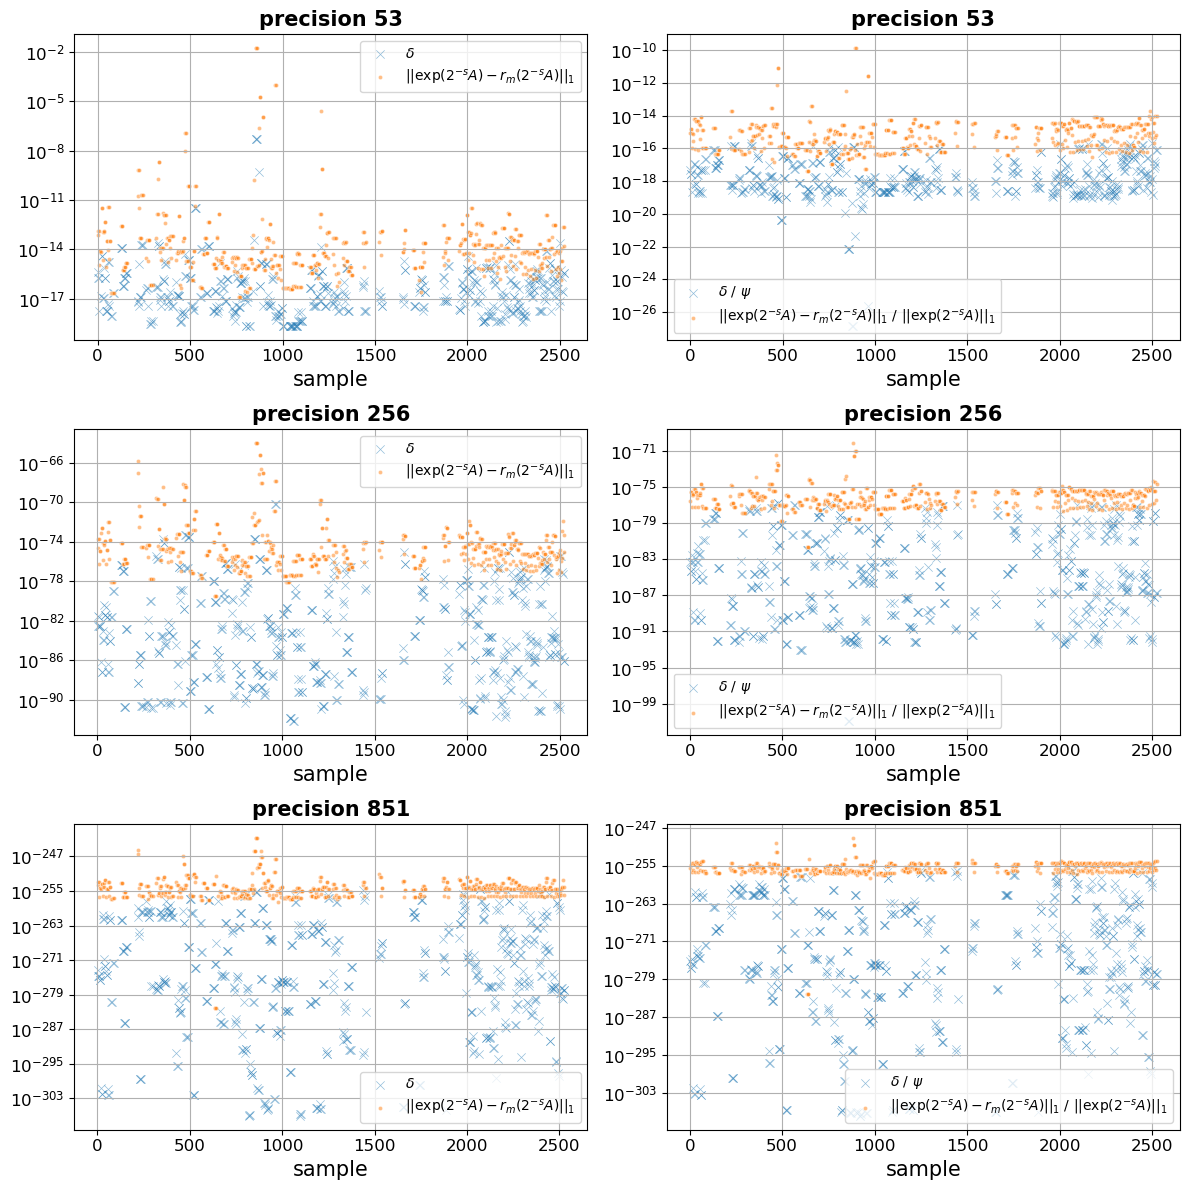

In [60]:
fig, axs = plt.subplots(len(WRK_PRECS),2, figsize=(4*len(WRK_PRECS),12))
#fig.suptitle(r"Upper bounds on the absolute (left) and relative (right) error", fontsize=16, fontweight="bold")

for i, prec in enumerate(WRK_PRECS):
    # delta and absolute error 
    df_delta_p = df_delta[df_delta["precision"]==prec]
    sns.scatterplot(x=df_delta_p["delta"].index, y=df_delta_p["delta"],
                    alpha=0.5, label=r"$\delta$",
                    marker='x',
                    #color="orange",
                    ax=axs[i,0])
    sns.scatterplot(x=df_delta_p["abs_err_1"].index, y=df_delta_p["abs_err_1"],
                    alpha=0.5, label=r"$\vert\vert\exp(2^{-s}A)-r_m(2^{-s}A)\vert\vert_1$",
                    marker='.',
                    #color="blue",
                    ax=axs[i,0])
    
    # delta and relative error
    y  = df_delta_p["abs_err_1"] / df_delta_p["nrm1_Yb4Sq_true"]
    y2 = df_delta_p["delta"].map(Decimal) / df_delta_p["psi"].map(Decimal)
    sns.scatterplot(x=y2.index, y=y2,
                    alpha=0.5, label=r"$\delta$ / $\psi$",
                    marker='x',
                    #color="orange",
                    ax=axs[i,1])
    sns.scatterplot(x=y.index, y=y,
                    alpha=0.5, label=r"$\vert\vert\exp(2^{-s}A)-r_m(2^{-s}A)\vert\vert_1$ / $\vert\vert\exp(2^{-s}A)\vert\vert_1$",
                    marker='.',
                    #color="blue",
                    ax=axs[i,1])

    for j in [0,1]:
        axs[i,j].set_title(f"precision {prec}", fontweight="bold", fontsize=15)
        axs[i,j].set_yscale("log")
        axs[i,j].set_xlabel("sample", fontsize=15)
        axs[i,j].set_ylabel("")
        axs[i,j].legend()
        axs[i,j].grid(True)
        axs[i,j].tick_params(axis='x', labelsize=12)
        axs[i,j].tick_params(axis='y', labelsize=12)


plt.tight_layout()
plt.show()

La situazione non è bella. L'errore assoluto è maggiore di $\delta$ per quasi tutti i samples... E questo è male.

Vediamo "di quanto ci stiamo sbagliando", plottando le differenze tra `delta` e `abs_err_1`

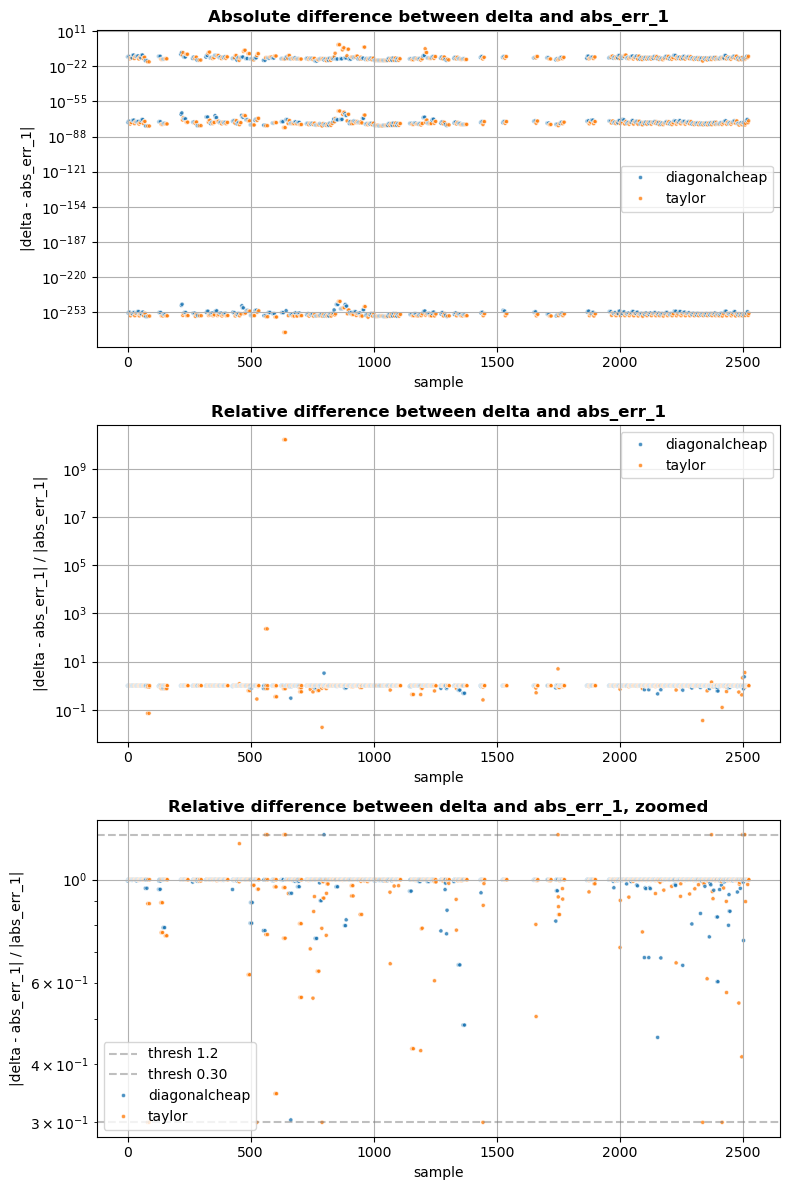

In [28]:
fig, axs = plt.subplots(3,1,figsize=(8,12))

# absolute
sns.scatterplot(x=df_delta.index, y=(df_delta["abs_err_1"] - df_delta["delta"].apply(Decimal)).abs(),
                hue=df_delta["approximant"], #style=df_delta["approximant"],
                marker='.', alpha=0.8,
                ax=axs[0])
axs[0].set_title("Absolute difference between delta and abs_err_1", fontweight="bold")
axs[0].set_yscale('log')
axs[0].set_ylabel("|delta - abs_err_1|")
axs[0].set_xlabel("sample")
axs[0].legend()
axs[0].grid(True)

# relative
y = abs(df_delta_delne0["delta"].apply(Decimal) - df_delta_delne0["abs_err_1"])/df_delta_delne0["abs_err_1"].apply(Decimal)
sns.scatterplot(x=df_delta_delne0.index, y=y,
               hue=df_delta_delne0["approximant"], #style=df_delta_delne0["approximant"],
               marker='.', alpha=0.8,
               ax=axs[1])
axs[1].set_title("Relative difference between delta and abs_err_1", fontweight="bold")
axs[1].set_yscale('log')
axs[1].set_ylabel("|delta - abs_err_1| / |abs_err_1|")
axs[1].set_xlabel("sample")
axs[1].legend()
axs[1].grid(True)

# relative, threshed
y = abs(df_delta_delne0["delta"].apply(Decimal) - df_delta_delne0["abs_err_1"])/df_delta_delne0["abs_err_1"].apply(Decimal)
high_thresh = Decimal(1.25)
low_thresh  = Decimal(3.0E-1)
axs[2].axhline(y=high_thresh,
               color="grey", alpha=0.5, linestyle="--",
               label=f"thresh {high_thresh:.2g}")
axs[2].axhline(y=low_thresh,
               color="grey", alpha=0.5, linestyle="--",
               label=f"thresh {low_thresh:.2g}")
sns.scatterplot(x=df_delta_delne0.index, 
                y=y.map(lambda x: high_thresh if x > high_thresh else low_thresh if x < low_thresh else x),
                hue=df_delta_delne0["approximant"], #style=df_delta_delne0["approximant"],
                marker='.', alpha=0.8,
                ax=axs[2])
axs[2].set_title("Relative difference between delta and abs_err_1, zoomed", fontweight="bold")
axs[2].set_yscale('log')
axs[2].set_ylabel("|delta - abs_err_1| / |abs_err_1|")
axs[2].set_xlabel("sample")
axs[2].legend()
axs[2].grid(True)

plt.tight_layout()
plt.show()

Proviamo a splittare per precisione, e per approssimante

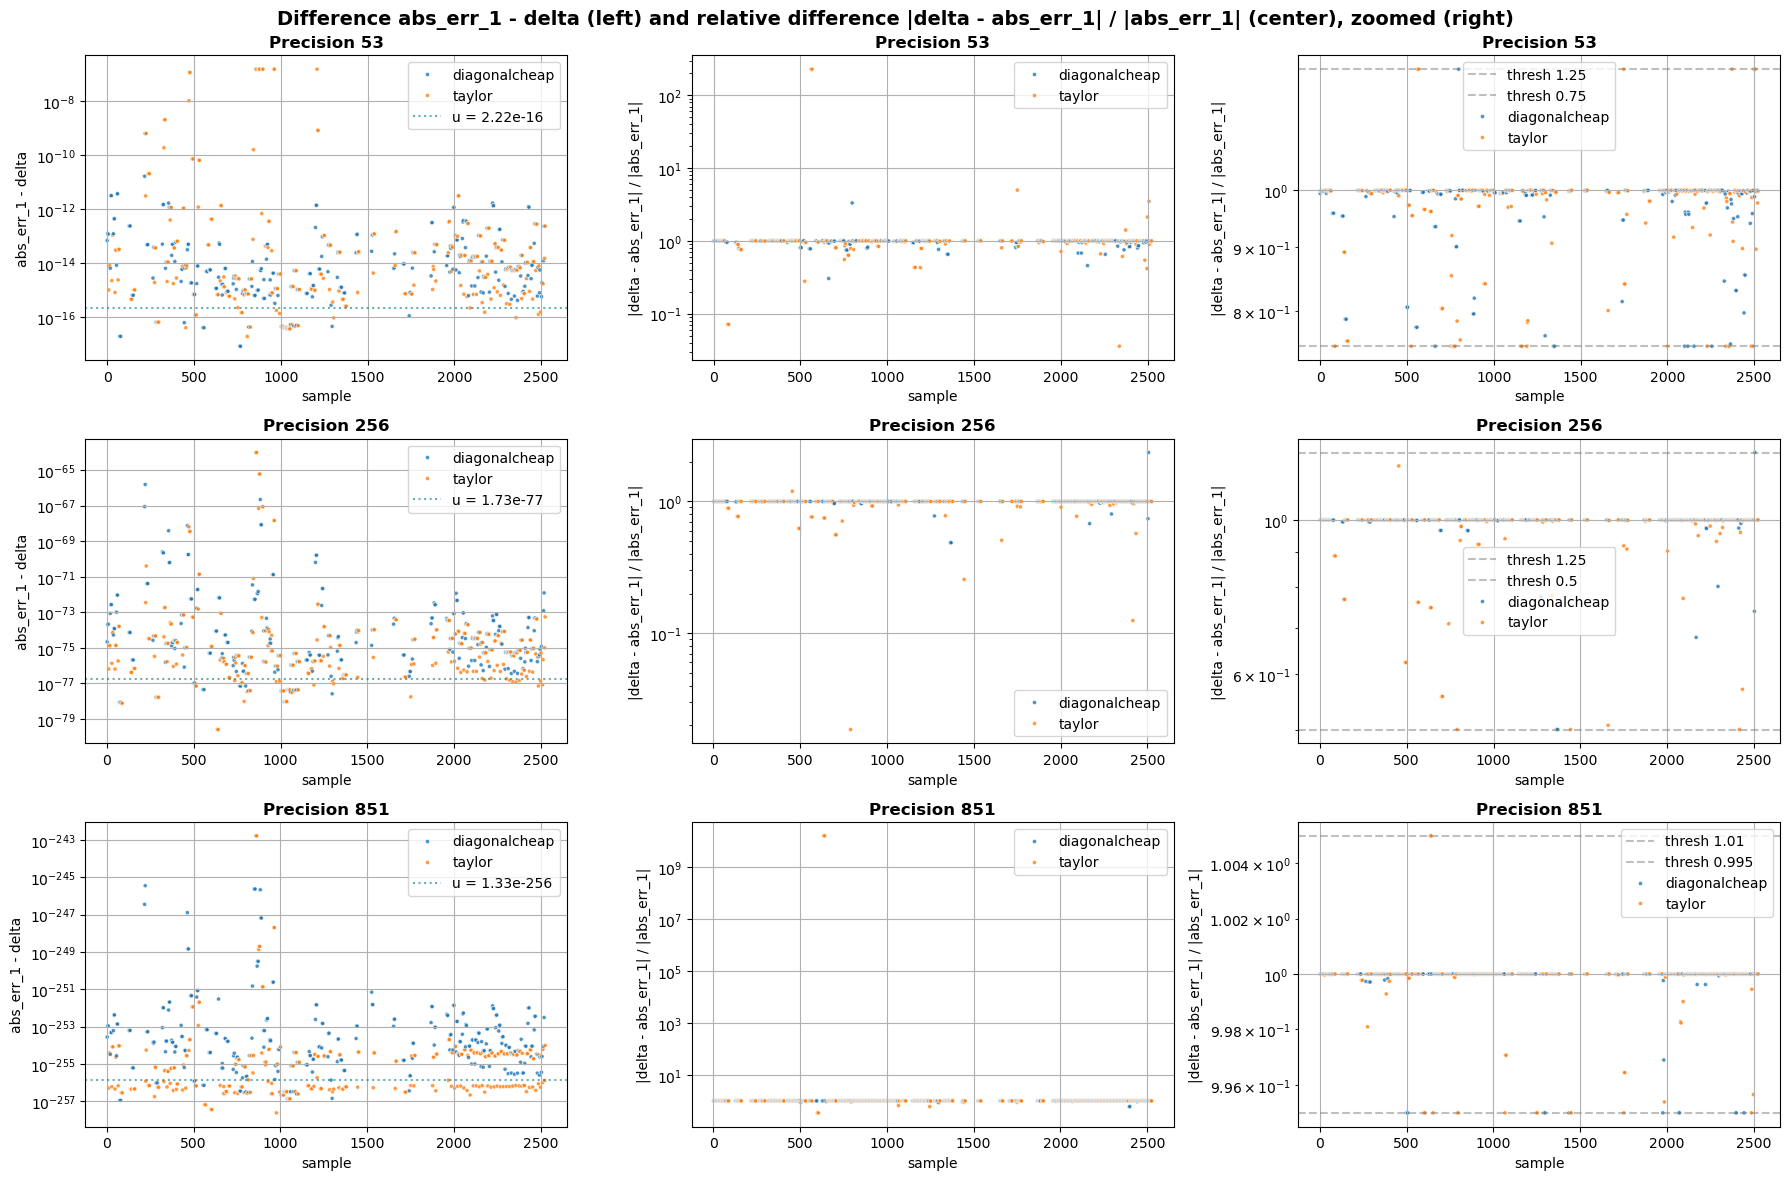

In [29]:
fig, axs = plt.subplots(len(WRK_PRECS),3, figsize=(18,4*len(WRK_PRECS)))
fig.suptitle("Difference abs_err_1 - delta (left) and relative difference |delta - abs_err_1| / |abs_err_1| (center), zoomed (right)", fontweight="bold", fontsize=14)

for i, prec in enumerate(WRK_PRECS):
    # absolute
    df_delta_p = df_delta[df_delta["precision"]==prec]
    y = (df_delta_p["abs_err_1"] - df_delta_p["delta"].apply(Decimal))
    thresh_abs = 10**(-221) if prec==851 else min(10.0**(-int(prec/2)*np.log10(2)+1), 10*max(y))
    #thresh_abs = np.inf
    sns.scatterplot(x=df_delta_p.index, y=y.map(lambda x: thresh_abs if x > thresh_abs else x),
                    hue=df_delta_p["approximant"], #style=df_delta_p["approximant"], 
                    alpha=0.8, marker='.',
                    ax=axs[i,0])
    u_p = 2*10**(-prec*np.log10(2))
    axs[i,0].axhline(y=u_p, 
                     color="teal", alpha=0.6, linestyle=":",
                     label=f"u = {u_p:.3g}")
    # axs[i,0].axhline(y=thresh_abs,
    #                  color="grey", alpha=0.6, linestyle="--",
    #                  label=f"thresh {thresh_abs:.3g}")
    axs[i,0].set_ylabel("abs_err_1 - delta")
    
    # relative
    df_delta_delne0_p = df_delta_delne0[df_delta_delne0["precision"]==prec]
    y = abs(df_delta_delne0_p["delta"].apply(Decimal) - df_delta_delne0_p["abs_err_1"])/df_delta_delne0_p["abs_err_1"]
    sns.scatterplot(x=df_delta_delne0_p.index, y=y,
               hue=df_delta_delne0_p["approximant"], #style=df_delta_delne0_p["approximant"],
               marker='.', alpha=0.8,
               ax=axs[i,1])
    axs[i,1].set_ylabel("|delta - abs_err_1| / |abs_err_1|")

    # relative, zoomed
    df_delta_delne0_p = df_delta_delne0[df_delta_delne0["precision"]==prec]
    y = abs(df_delta_delne0_p["delta"].apply(Decimal) - df_delta_delne0_p["abs_err_1"])/df_delta_delne0_p["abs_err_1"]
    # mettiamo delle soglie per migliorare la resa grafica. Sennò i punti son tutti appiccicati
    thresh_rel_high = {
        53:  Decimal(1.0)+Decimal(2.5E-1),
        256: Decimal(1.0)+Decimal(2.5E-1),
        851: Decimal(1.0)+Decimal(5.0E-3)
    }
    axs[i,2].axhline(y=thresh_rel_high[prec],
                     color="grey", alpha=0.5, linestyle="--",
                     label=f"thresh {thresh_rel_high[prec]:.3g}")
    thresh_rel_low = {
        53:  Decimal(1.0)-Decimal(2.5E-1),
        256: Decimal(1.0)-Decimal(5.0E-1),
        851: Decimal(1.0)-Decimal(5.0E-3)
    }
    axs[i,2].axhline(y=thresh_rel_low[prec],
                     color="grey", alpha=0.5, linestyle="--",
                     label=f"thresh {thresh_rel_low[prec]:.3g}")
    sns.scatterplot(x=df_delta_delne0_p.index, 
                y=y.map(lambda x: thresh_rel_high[prec] if x > thresh_rel_high[prec] else thresh_rel_low[prec] if x < thresh_rel_low[prec] else x),
                hue=df_delta_delne0_p["approximant"], #style=df_delta_delne0_p["approximant"],
                marker='.', alpha=0.8,
                ax=axs[i,2])
    axs[i,2].set_ylabel("|delta - abs_err_1| / |abs_err_1|")
    
    for j in [0,1,2]:
        axs[i,j].set_title(f"Precision {prec}", fontweight="bold")
        axs[i,j].set_yscale("log")
        axs[i,j].set_xlabel("sample")
        axs[i,j].legend()
        axs[i,j].grid(True)

plt.tight_layout()
plt.show()

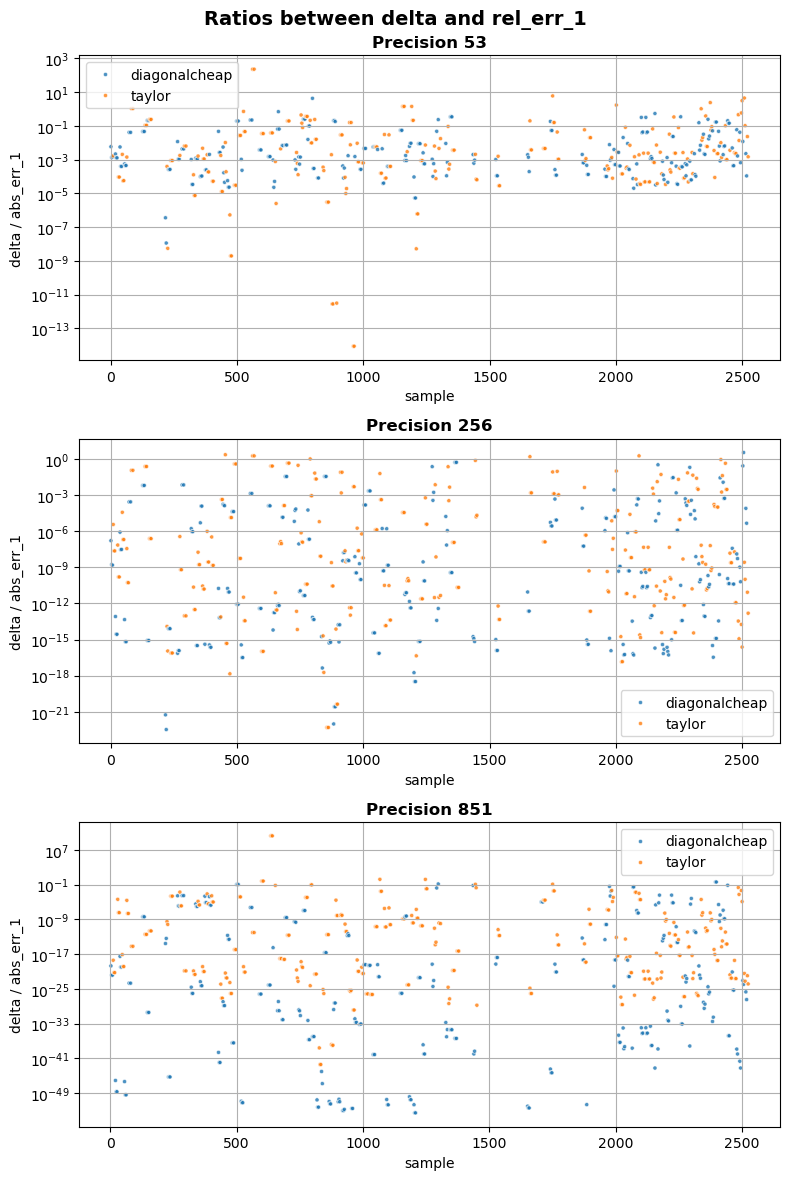

In [30]:
fig, axs = plt.subplots(len(WRK_PRECS),1, figsize=(8,4*len(WRK_PRECS)))
fig.suptitle("Ratios between delta and rel_err_1", fontweight="bold", fontsize=14)

for i, prec in enumerate(WRK_PRECS):
    df_delta_delne0_p = df_delta_delne0[df_delta_delne0["precision"]==prec]
    y = df_delta_delne0_p["delta"].map(Decimal)/df_delta_delne0_p["abs_err_1"]
    sns.scatterplot(x=y.index, y=y,
                    hue=df_delta_delne0_p["approximant"],
                    alpha=0.8, marker='.',
                    ax=axs[i])
    axs[i].set_title(f"Precision {prec}", fontweight="bold")
    axs[i].set_xlabel("sample")
    axs[i].set_ylabel("delta / abs_err_1")
    axs[i].set_yscale("log")
    axs[i].legend()
    axs[i].grid(True)

plt.tight_layout()
plt.show()

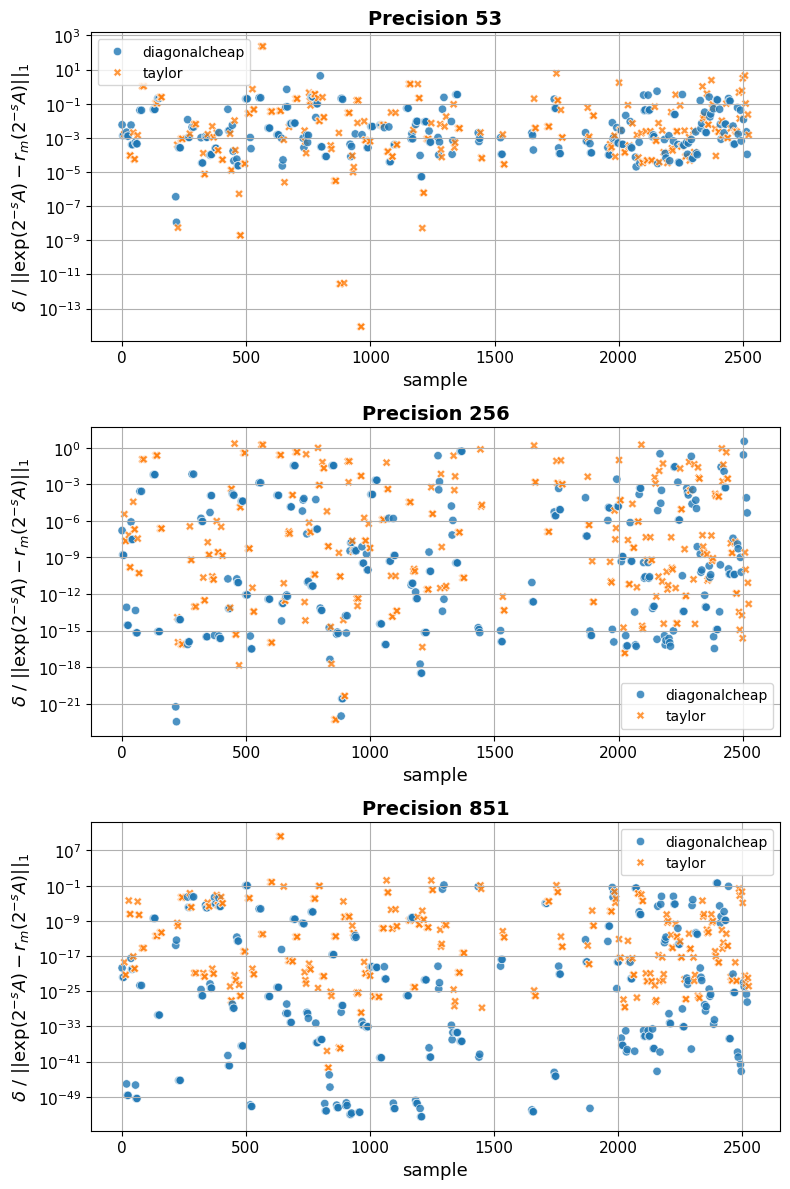

In [80]:
fig, axs = plt.subplots(len(WRK_PRECS),1, figsize=(8,4*len(WRK_PRECS)))
#fig.suptitle("Ratios between delta and rel_err_1", fontweight="bold", fontsize=14)

for i, prec in enumerate(WRK_PRECS):
    df_delta_delne0_p = df_delta_delne0[df_delta_delne0["precision"]==prec]
    y = df_delta_delne0_p["delta"].map(Decimal)/df_delta_delne0_p["abs_err_1"]
    sns.scatterplot(x=y.index, y=y,
                    hue=df_delta_delne0_p["approximant"],
                    style=df_delta_delne0_p["approximant"],
                    alpha=0.8, #marker='o',
                    ax=axs[i])
    axs[i].set_title(f"Precision {prec}", fontweight="bold", fontsize=14)
    axs[i].set_xlabel("sample", fontsize=13)
    axs[i].set_ylabel(r"$\delta$ / $\vert\vert\exp(2^{-s}A)-r_m(2^{-s}A)\vert\vert_1$", fontsize=13)
    axs[i].set_yscale("log")
    axs[i].tick_params(axis='x', labelsize=11)
    axs[i].tick_params(axis='y', labelsize=11)
    axs[i].legend()
    axs[i].grid(True)

plt.tight_layout()
plt.show()

A sinistra abbiamo plottato `abs_err_1 - delta`, senza valori assoluti. Non è scoppiato niente nonostante la scala logaritmica. Temo sia un segno che effettivamente $\delta$ è minore dell'errore assoluto.

In effetti il criterio di arresto dell'algoritmo è 
$$
    \delta < u * \psi
$$
dove $\psi=r_m(2^{-s}A)\approx\exp(2^{-s}A)$. Almeno questo è rispettato?

In [60]:
stop_criterion_satisfied = df_delta["delta"].dropna()/df_delta["psi"] < df_delta["precision"]

print(f"The stopping criterion is satisfied in {sum(stop_criterion_satisfied)} is out of {df_delta.shape[0]} samples")

The stopping criterion is satisfied in 1832 is out of 1832 samples


Buone notizie. Era scontata come cosa, però.

Ok. $\delta$ non è in generale un upper bound all'errore assoluto. Ci chiediamo però se ci sono casi in cui $\delta$ non limita l'errore assoluto, ma vale $\mathtt{err\_rel}\le\delta/\psi$. 

### Intermezzi: quantità che sono `NaN`

Alcune quantità sono `NaN`. Alcune le ho messe io: ad esempio
- nell'opzione Scaling and Squaring molti parametri sono `NaN` perché non sono proprio calcolati!
- Se $A$ è Hermitiana, o diagonale, l'algoritmo diagonalizza, quindi parametri come `m`, `s` etc sono `NaN`

#### Intermezzo 1: e se $\kappa_{\exp}(A)$ è `NaN`?

Per qualche matrice, il numero di condizionamento calcolato è `NaN`. Vediamo quali sono 

In [29]:
print("Is `cond_expA_F` a NaN value?")
display(df["cond_expA_F"].isna().value_counts())

print(f"The matrices for which `cond_expA_F` is NaN are: {', '.join(df[df["cond_expA_F"].isna()]["kind"].unique())}")

print("This is `ChainRule.rrule(exp, A)`'s fault (I checked)")

Is `cond_expA_F` a NaN value?


cond_expA_F
False    2594
True       76
Name: count, dtype: int64

The matrices for which `cond_expA_F` is NaN are: Fasi_6, Fasi_7, Fasi_11, dorr_10_100.0
This is `ChainRule.rrule(exp, A)`'s fault (I checked)


Vediamo quali sono queste matrici, facendo una discussione un po' più approfondita

##### La matrice `Fasi6`

La matrice `Fasi6` è ottenuta tramite 
```
A = diagm([0, 1, 1e6])
```
Il suo esponenziale si può calcolare esattamente come 
```
Y_true = exp(Diagonal([0, 1, big(1e6)]))
```

Notiamo subito che gli elementi di `A` sono di ordini di grandezza radicalmente diversi.

Avevamo fatto un'analisi approfondita io e il professore, a ricevimento. Quel che succede è che:
- A è hermitiana. 
- Nella funzione `cond_exp_exact(A)`, Quando si esegue `Y_true, exp_pullback = ChainRules.rrule(exp, A)`, si fa riferimento al branch `ishermitian(A0)` della `function rrule` in `ChainRules.matfun` 
    - Insomma quello che avevo trovato su GitHub
    - Per trovarlo: `@edit ChainRules.rrule(exp, A)`. Comunque è alla riga 119
- Alla riga 122, si calcolano $\exp(A)$ e delle quantità intermedie (sono `hermX` e `hermX_intermediates`)
    - A restituirle, è la funzione `_matfun` presente in `ChainRules/rulesets/LinearAlgebra/symmetric.jl` (riga 373). 
    - Questa funzione fa:
        - `λ, U = eigen(A)`, ossia la decomposizione spettrale di `Hermitian(A)`
        - dopodiché, essenzialmente, viene eseguita `fλ_df_dλ = map(λi -> frule((ZeroTangent(), true), exp, λi), λ)`
        
Insomma quel che succede è che `exp(1e6)` viene valutato come `Inf`.

Diamo una minima spiegazione di `fλ_df_dλ = map(λi -> frule((ZeroTangent(), true), f, λi), λ)`
- `map(λi -> g(λi), λ)` La solita map. Calcola `g` su ogni elemento `λi` di `λ`
- `frule((ZeroTangent(), true), exp, λi)`. Questa è la forward rule. A volte la si chiama *pushforward*
    - Input: `(ZeroTangent(), true)`: sono gli "incrementi infinitesimi" della funzione stessa (in Julia terms, `\Delta self`) e dell'input. `exp`: la funzione di cui si vuole il pushforward. `λi`: punto dove si vuole valutare la derivata
    - Output: `exp(λi)` e `exp'(λi) * true`, dove `exp'` denota la derivata. Essendo in una variabile è tutto facile e la posso chiamare `exp'`. In generale, restituisce la derivata di `exp` calcolata in `λi` lungo la direzione `true` (*oss*: le `rrule`s sono in grado di restituire "l'oggetto che agisce")

##### La matrice `Fasi7`

La matrice `Fasi7` è ottenuta tramite 
```
A = [1e-4 0; 0 1e4]
```


Il calcolo del numero di condizionamento fallisce esattamente per i motivi descritti prima per `Fasi6` (`exp(1e4) = Inf`)

##### La matrice `Fasi11`

La matrice `Fasi11` è ottenuta tramite 
```
A = [1 1e3; 1e3 1]
```
Probabilmente c'è una formula per l'esponenziale esatto, ma non viene calcolato.

Succede proprio la stessa cosa delle precedenti: gli autovalori di `A` sono $-999$ e $1001$. Quando si va a eseguire `frule((ZeroTangent(), true), exp, λi)` per `λi=1001` il risultato è `Inf`

##### La matrice `dorr_10_100.0`

La matrice `dorr_10_100.0` è ottenuta tramite
```
Dorr(10, 100.0)
```
dunque tramite `TypedMatrices`. La documentazione dice che è dominante diagonale, malcondizionata e tridiagonale.

Eseguendo `Y_true, exp_pullback = ChainRules.rrule(exp, Matrix(A))`
otteniamo che `Y_true` è una matrice con elementi `Inf` e `-Inf`. Ovviamente, `exp(A)` restituisce la stessa matrice

Durante l'esecuzione, vengono sollevati due errori: `On entry to DLASCL parameter number 4 had an illegal value` e `On entry to DLASCL parameter number 5 had an illegal value`. Pare roba di LAPACK...

#### Intermezzo 2: e se `rel_err_F` è `NaN`?

In [30]:
df[df["rel_err_F"].isna()]

,kind,n,eltype,ishermitian,approximant,algorithm,schur_time,alpha_time,eval_bound_time,eval_pade_time,...,cond_q,epsilon,rel_err_F,abs_err_1,nrm1_Ytrue,Ytrue_method,cond_expA_F,condA_1,condA_2,precision
684,kela89_206,4,Int64,False,diagonalcheap,complexschur,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,245.994433163083,mpmath_1792,3303.306709,133926.0,106351.051985,851
687,kela89_206,4,Int64,False,diagonalcheap,realschur,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,245.994433163083,mpmath_1792,3303.306709,133926.0,106351.051985,851
693,kela89_206,4,Int64,False,taylor,complexschur,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,245.994433163083,mpmath_1792,3303.306709,133926.0,106351.051985,851
696,kela89_206,4,Int64,False,taylor,realschur,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,245.994433163083,mpmath_1792,3303.306709,133926.0,106351.051985,851


In questo esempio è tutto `NaN` in realtà perché è la decomposizione di Schur a fallire. Non è colpa mia dai

### Errore ottenuto

Vediamo se il classico bound 
$$
    \frac{\lvert\lvert\hat{Y}-Y\rvert\rvert}{\lvert\lvert Y\rvert\rvert} \lesssim O(u)\cdot\kappa_{\exp}(A)
$$
è rispettato.

In [31]:
def relerr_satisfies_bound_within_factor(df, k=0):
    return df.apply(lambda r: r["rel_err_F"] <= (r["n"]**k) * r["epsilon"] * r["cond_expA_F"], axis=1)

print(f"Out of {df.shape[0]} samples:")
print(f"\t{sum(relerr_satisfies_bound_within_factor(df, 0))} are such that the relative error is bounded by u * k")
print(f"\t{sum(relerr_satisfies_bound_within_factor(df, 1))} are such that the relative error is bounded by n * u * k")
print(f"\t{sum(relerr_satisfies_bound_within_factor(df, 2))} are such that the relative error is bounded by n^2 * u * k")

print("where:\n\tu = machine precision,\n\tk = conditioning of the exponential of the input,\n\tn = matrix size")

Out of 2670 samples:
	1424 are such that the relative error is bounded by u * k
	2389 are such that the relative error is bounded by n * u * k
	2453 are such that the relative error is bounded by n^2 * u * k
where:
	u = machine precision,
	k = conditioning of the exponential of the input,
	n = matrix size


In [32]:
df_pivot = df[(df["approximant"]!="scaling_and_squaring") & 
              (~df["cond_expA_F"].isna())]

error_bounded_n2 = relerr_satisfies_bound_within_factor(df_pivot,2)

df_pivot = df_pivot.assign(relerr_satisfies_bound_n=error_bounded_n2)

table = pd.pivot_table(df_pivot,
                       values="relerr_satisfies_bound_n",
                       index=["approximant", "algorithm"], columns="precision",
                       #aggfunc={"sum", "mean", "count"})
                       aggfunc={"sum", "mean"})

table

mean                      sum          
precision                        53        256       851  53   256  851
approximant   algorithm                                                
diagonalcheap complexschur  0.950000  0.950000  0.942857  133  133  132
              realschur     0.945736  0.945736  0.937984  122  122  121
              transfree     0.942857  0.942857  0.950000  132  132  133
taylor        complexschur  0.950000  0.950000  0.942857  133  133  132
              realschur     0.945736  0.945736  0.937984  122  122  121
              transfree     0.950000  0.950000  0.942857  133  133  132

Ma quanto mi piacciono queste tabelle pivot autistiche mamma mia...

Non è immediato da leggere, ma c'è tutto. Per ogni configurazione di `approximant`, `algorithm` e `precision` stiamo contando quanti campioni soddisfano il bound sull'errore (e c'è anche la percentuale di quanti lo fanno)

***OSS***: La tabella precedente esclude i casi in cui il numero di condizionamento è `NaN`, ma include quelli in cui la forma di Schur ha fallito!

#### Plots

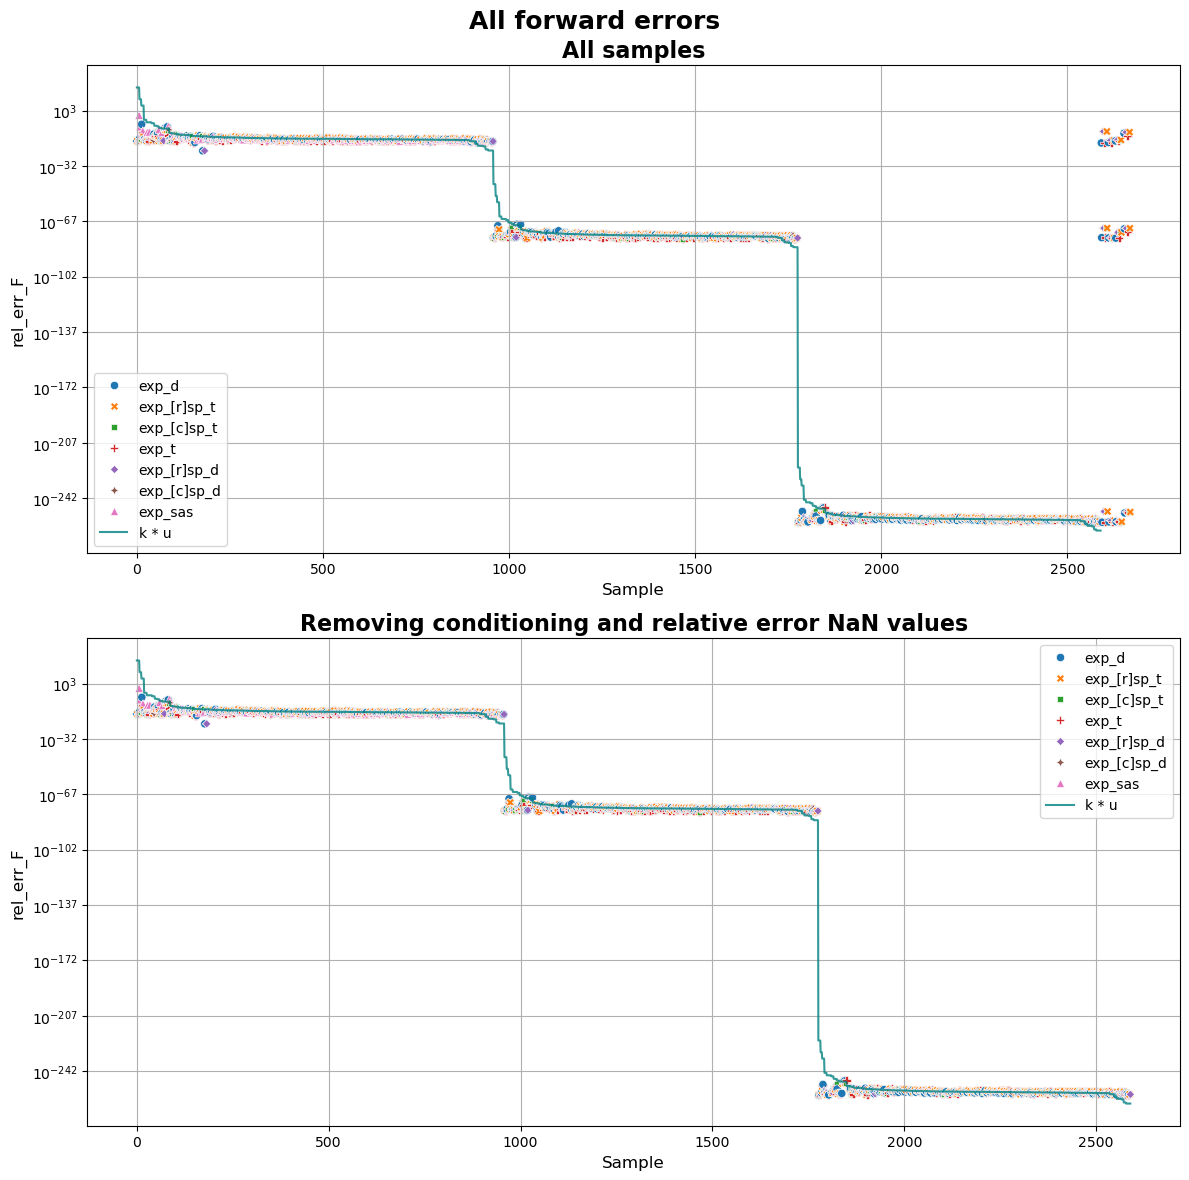

In [33]:
fig, axs = plt.subplots(2,1,figsize=(12,12))
fig.suptitle("All forward errors", fontsize=18, fontweight="bold")

axs[0].set_title("All samples", fontsize=16, fontweight="bold")
produce_plot(df, axs[0])

axs[1].set_title("Removing conditioning and relative error NaN values", fontsize=16, fontweight="bold")
produce_plot(df.dropna(subset=["rel_err_F", "cond_expA_F"]), axs[1])

plt.tight_layout()
plt.show()

Vediamo i plots separati per precisione. Escludiamo inoltre i samples per i quali il numero di condizionamento dell'esponenziale non è stato calcolato.

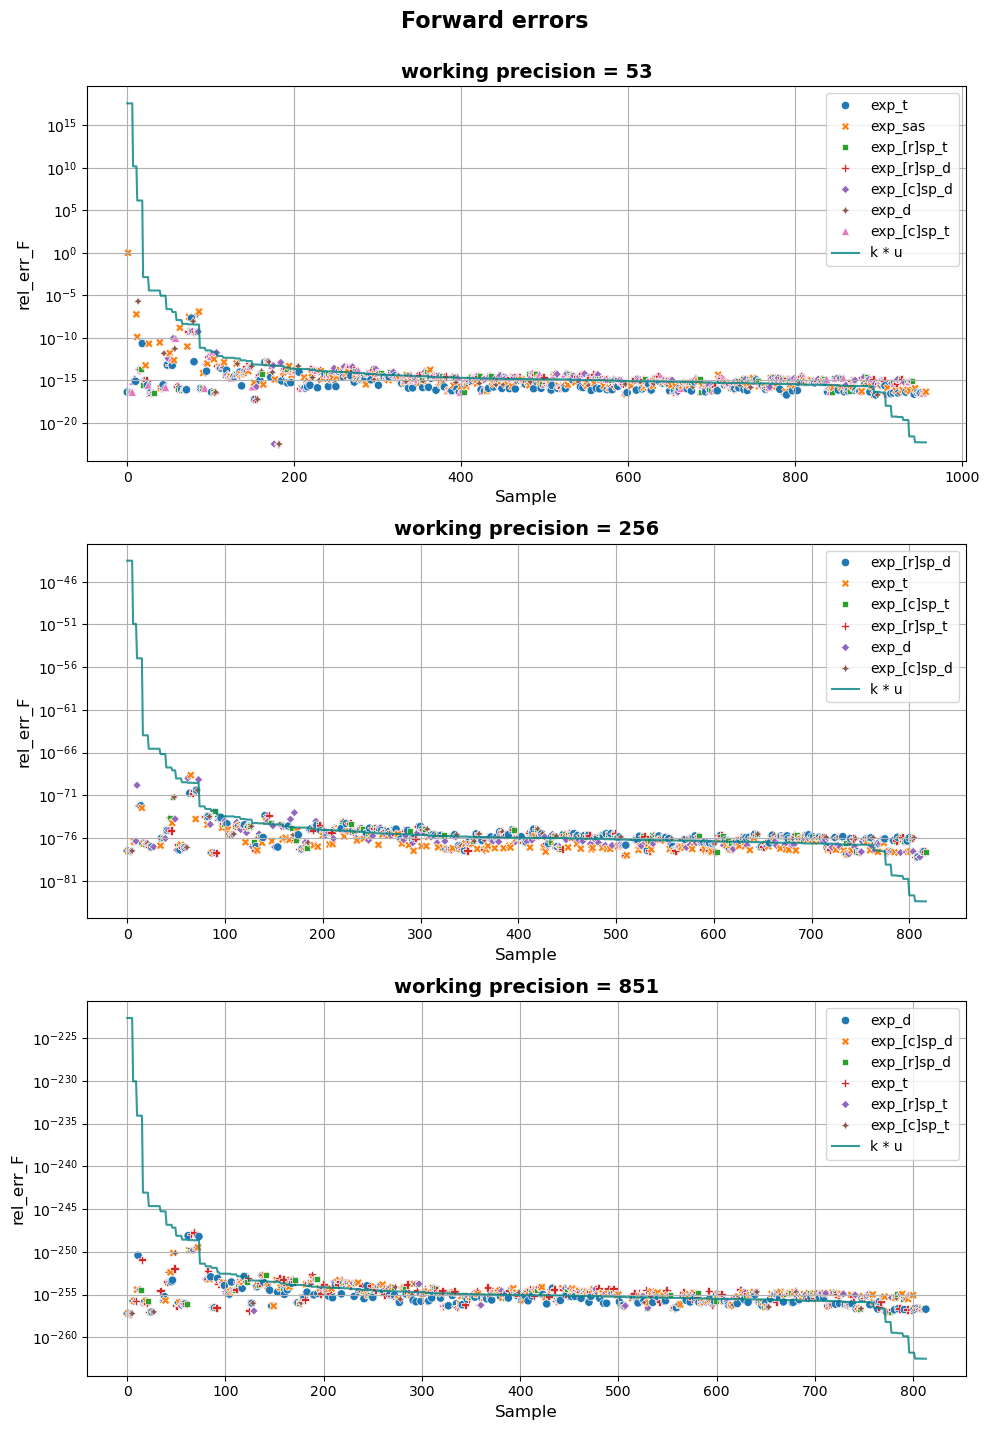

In [34]:
WRK_PRECS = df["precision"].unique()

fig, axs = plt.subplots(len(WRK_PRECS), 1, figsize=(10, 5*len(WRK_PRECS)))
fig.suptitle("Forward errors", fontsize=16, fontweight="bold")

for i, wp in enumerate(WRK_PRECS):
    axs[i].set_title(f"working precision = {wp}", fontsize=14, fontweight="bold")
    df_inn = df[df["precision"] == wp]
    # escludiamo campioni con condiz e rel_err NaN (discussi a parte)
    df_inn = df_inn.dropna(subset=["cond_expA_F", "rel_err_F"])
    produce_plot(df_inn, axs[i])

plt.tight_layout(rect=[0, 0.03, 1, 0.98])
plt.show()

Boh a occhio sembrano grosso modo gli stessi risultati degli autori. Beh, forse la scala andrebbe un pochino ristretta

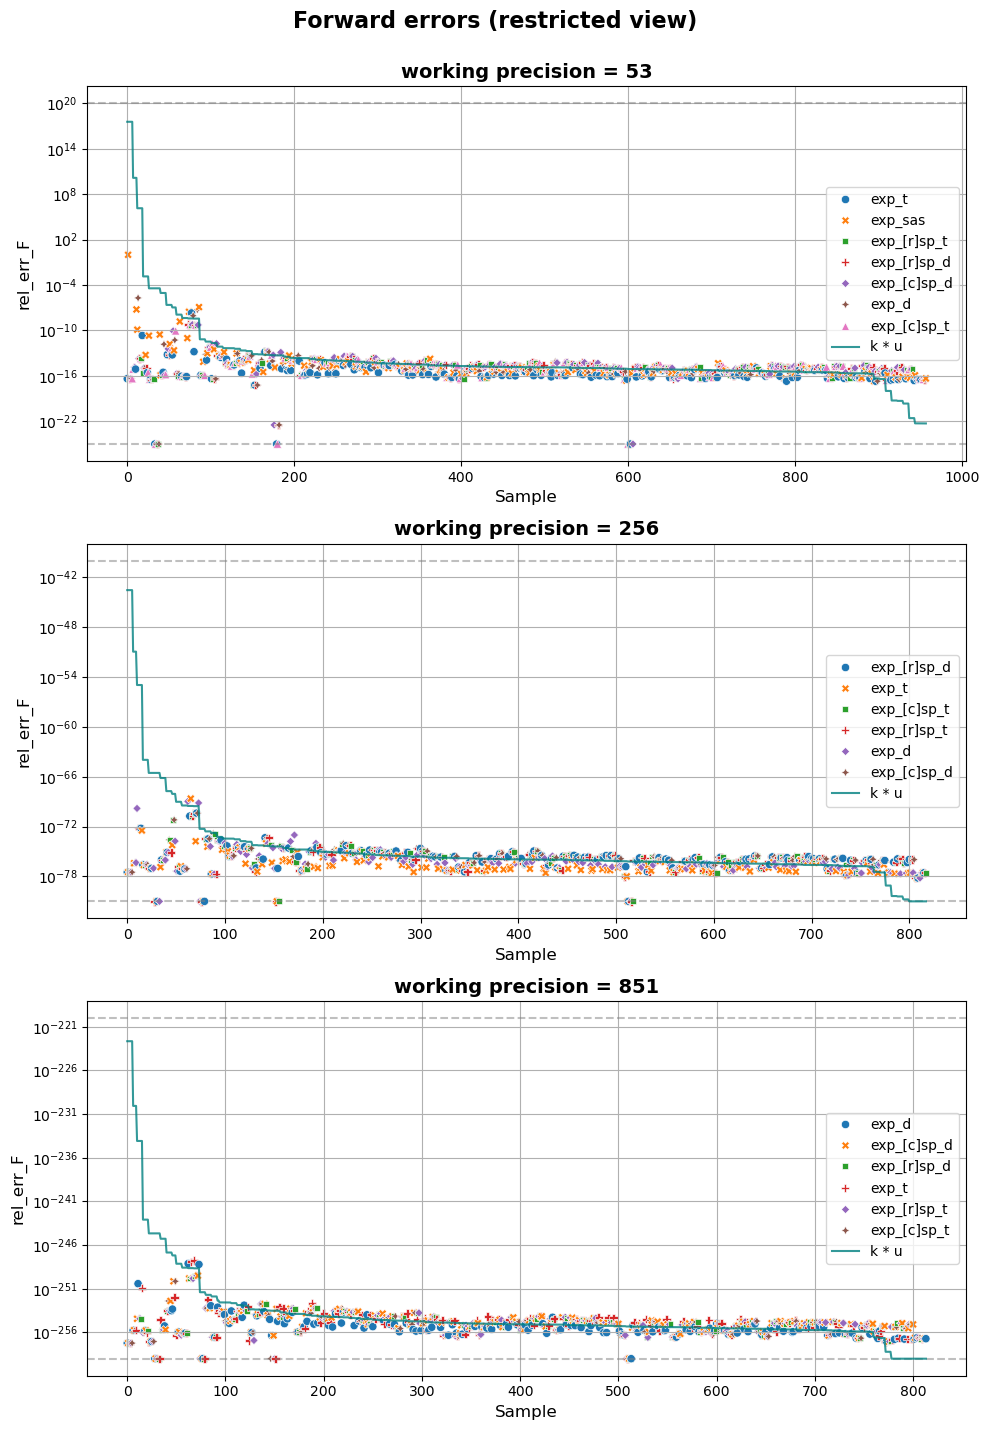

In [35]:
WINDOWS = [(1e-25, 1e20), (1e-81, 1e-40), (1e-259, 1e-220)]

fig, axs = plt.subplots(len(WRK_PRECS), 1, figsize=(10, 5*len(WRK_PRECS)))
fig.suptitle("Forward errors (restricted view)", fontsize=16, fontweight="bold")

for i, (wp, win) in enumerate(zip(WRK_PRECS, WINDOWS)):
    axs[i].set_title(f"working precision = {wp}", fontsize=14, fontweight="bold")
    df_inn = df[df["precision"] == wp]
    # escludiamo campioni con condiz e rel_err NaN (discussi a parte)
    df_inn = df_inn.dropna(subset=["cond_expA_F", "rel_err_F"])
    produce_plot(df_inn, axs[i], window=win)

plt.tight_layout(rect=[0, 0.03, 1, 0.98])
plt.show()

Non sembra affatto male!!

Facciamone una versione più idonea alla tesi. Cheese!

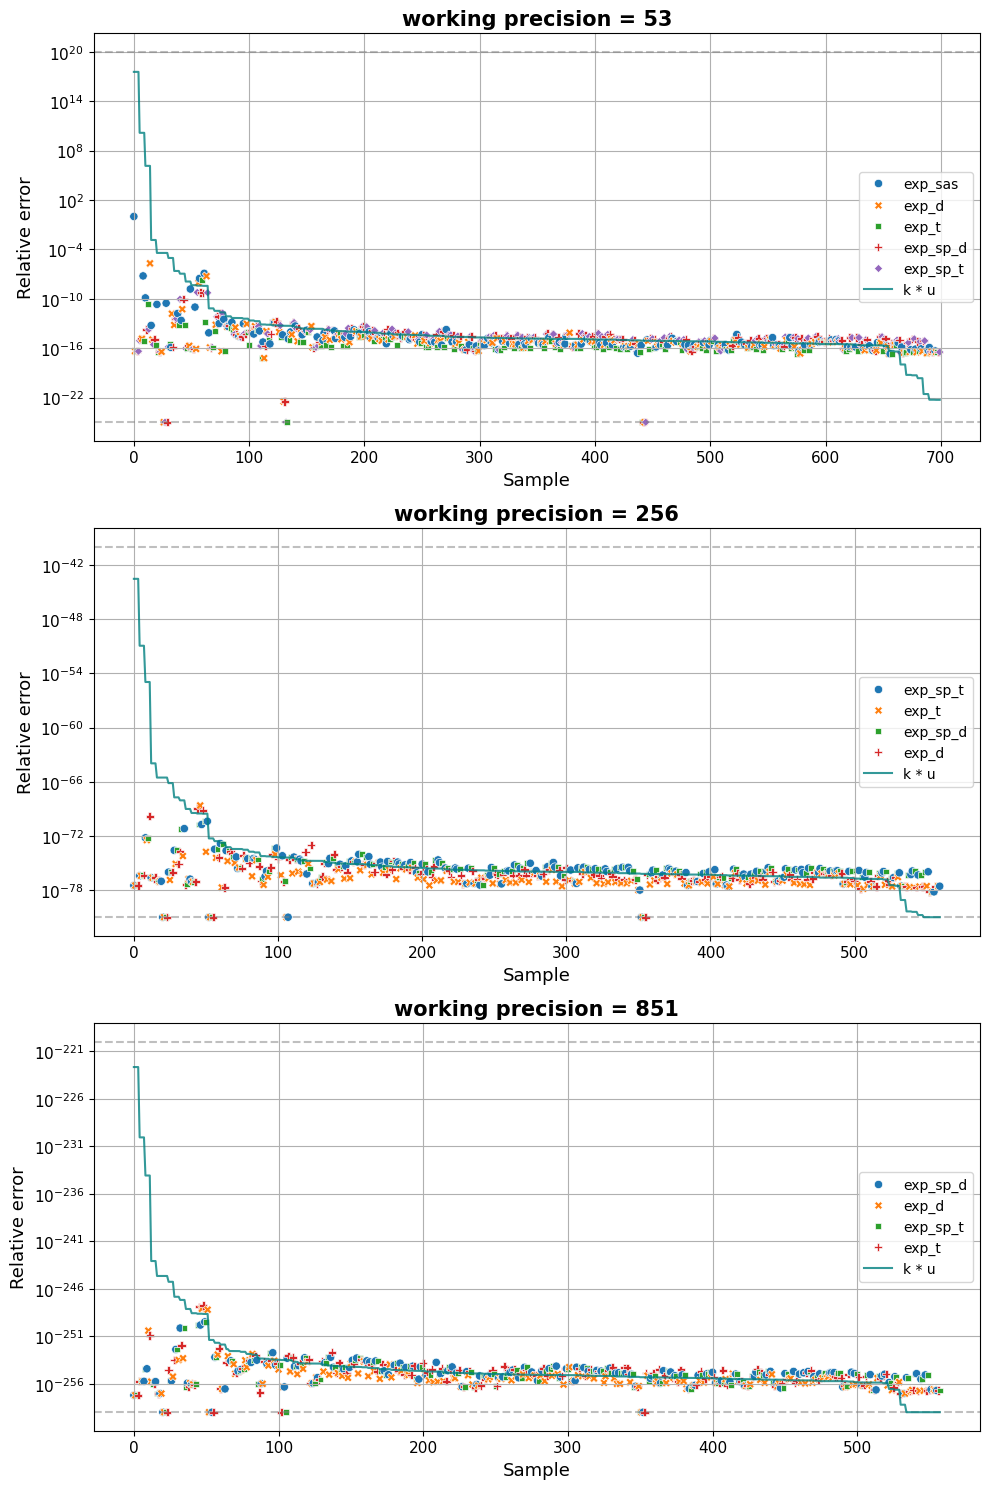

In [36]:
WINDOWS = [(1e-25, 1e20), (1e-81, 1e-40), (1e-259, 1e-220)]

fig, axs = plt.subplots(len(WRK_PRECS), 1, figsize=(10, 5*len(WRK_PRECS)))
#fig.suptitle("Forward errors (restricted view)", fontsize=16, fontweight="bold")

for i, (wp, win) in enumerate(zip(WRK_PRECS, WINDOWS)):
    axs[i].set_title(f"working precision = {wp}", fontsize=15, fontweight="bold")
    df_inn = df[df["precision"] == wp]
    # Consideriamo solo forma di Schur complessa
    df_inn = df_inn[~(df_inn["algorithm"]=="realschur")]
    df_inn["algorithm"] = df_inn["algorithm"].map(lambda x: "schur" if (x is not np.nan and "schur" in x) else x)
    # escludiamo campioni con condiz e rel_err NaN (discussi a parte)
    df_inn = df_inn.dropna(subset=["cond_expA_F", "rel_err_F"])
    produce_plot(df_inn, axs[i], window=win)
    axs[i].tick_params(axis="both", labelsize=11)
    axs[i].set_xlabel("Sample", fontsize=13)
    axs[i].set_ylabel("Relative error", fontsize=13)

plt.tight_layout()
plt.show()

Bellooooo!!!

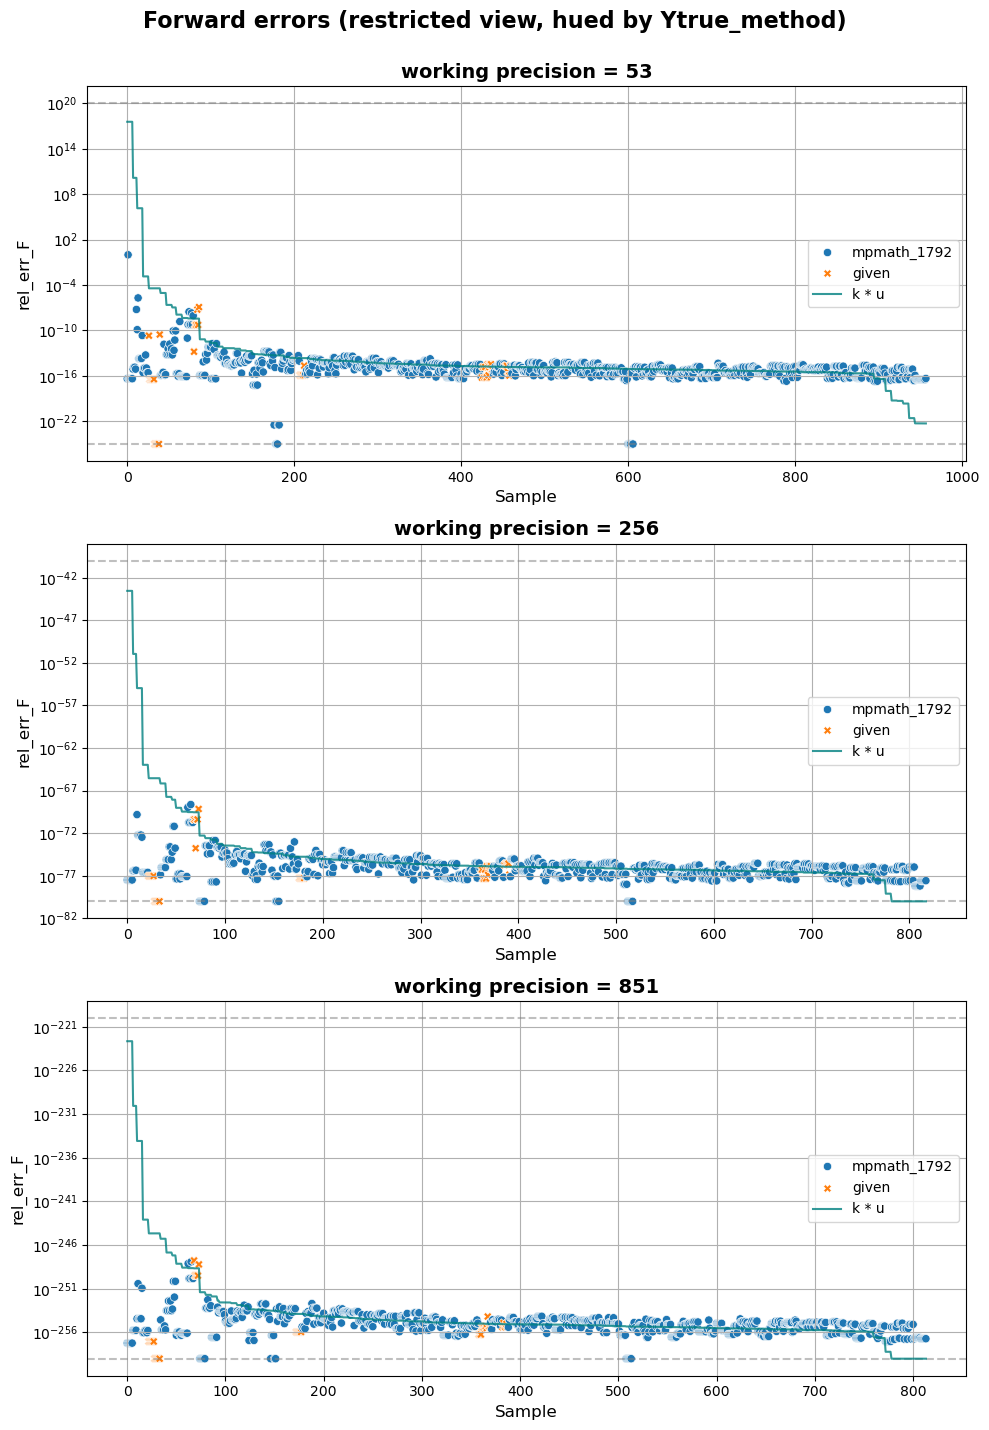

In [37]:
WINDOWS = [(1e-25, 1e20), (1e-80, 1e-40), (1e-259, 1e-220)]

fig, axs = plt.subplots(len(WRK_PRECS), 1, figsize=(10, 5*len(WRK_PRECS)))
fig.suptitle("Forward errors (restricted view, hued by Ytrue_method)", fontsize=16, fontweight="bold")

for i, (wp, win) in enumerate(zip(WRK_PRECS, WINDOWS)):
    axs[i].set_title(f"working precision = {wp}", fontsize=14, fontweight="bold")
    df_inn = df[df["precision"] == wp]
    # escludiamo campioni con condiz e rel_err NaN (discussi a parte)
    df_inn = df_inn.dropna(subset=["cond_expA_F", "rel_err_F"])
    produce_plot(df_inn, axs[i], hue="Ytrue_method", window=win)

plt.tight_layout(rect=[0, 0.03, 1, 0.98])
plt.show()

Quali matrici, in particolare, hanno samples off-the-charts?

In [38]:
print("The following matrices are just off the charts!")

for prec, (_, up) in zip(WRK_PRECS, WINDOWS):
    df_p = df_p = df[df["precision"]==prec].dropna(subset=["cond_expA_F", "rel_err_F"])
    print(f"For precision = {prec}:", end=" ")
    indici_p_notLe = df_p[df_p["rel_err_F"] > up].index
    names = df_p.loc[indici_p_notLe, "kind"].unique()
    for i in range(0, len(names), 5):
        print(", ".join(names[i:i+5]))
    print()

The following matrices are just off the charts!
For precision = 53: 
For precision = 256: 
For precision = 851: 


Nessuna!!! :D

#### Matrici approssimate male

Vediamo quali sono le matrici per i quali abbiamo valori molto alti dell'errore relativo

*Non* stiamo escludendo quei samples per il quale l'errore non è stato calcolato (cfr. Intermezzo 2).

Ossia, per la precisione 851, alcuni samples corrispondenti alla matrice `kela89_206` *sono* contati tra quelli per il quale il bound non è rispettato. Inoltre, la matrice è elencata tra quelle per il quale il bound non è rispettato

***OSS***: Questo è vero per tutte le matrici. Se c'è anche solo un sample per il quale il bound non vale, la matrice è elencata.

In [39]:
all_names = dict()
all_nums = dict()

for prec in WRK_PRECS:
    df_p = df[df["precision"]==prec].dropna(subset=["cond_expA_F"])
    all_nums[prec] = df_p.shape[0] - sum(relerr_satisfies_bound_within_factor(df_p, 2))

    # indici_p_notLe come sotto *include* anche i samples con rel_err_F = NaN
    indici_p_notLe = df_p[~(relerr_satisfies_bound_within_factor(df_p, 2))].index
    # indici_p_notLe come sotto *esclude* i samples con rel_err_F = NaN
    #indici_p_notLe = df_p.apply(lambda x: x["rel_err_F"] > x["cond_expA_F"] * x["epsilon"] * x["n"]**2, axis=1)
    
    all_names[prec] = set(df_p.loc[indici_p_notLe, "kind"].unique())

comuni = set.intersection(*all_names.values())
print("Matrices that don't satisfy the n^2 * u * k bound, for all precisions:")
for i, matrix in enumerate(sorted(comuni), start=1):
    end = ", " if i % 3 else "\n"
    prefix = "\t" if i % 3 == 1 else ""
    print(prefix + matrix, end=end)
if len(comuni) % 3 != 0:
    print("")

print()
for prec in WRK_PRECS:
    print(f"Matrices that don't satisfy the bound, specifically in precision {prec}:")
    print(f"\t {all_names[prec] - comuni}", end="\t")
    print(f"({all_nums[prec]} samples in total)")



Matrices that don't satisfy the n^2 * u * k bound, for all precisions:
	kase99_table1, lara17_benchmark1, lara17_benchmark2
	lara17_benchmark3, lara17_benchmark4, lara17_benchmark5
	lara17_benchmark6, 

Matrices that don't satisfy the bound, specifically in precision 53:
	 {'awad_27'}	(51 samples in total)
Matrices that don't satisfy the bound, specifically in precision 256:
	 {'Fasi_17'}	(43 samples in total)
Matrices that don't satisfy the bound, specifically in precision 851:
	 {'kela89_206', 'awad_27'}	(47 samples in total)


Vediamo "il peggio quanto è cattivo"

In [40]:
for name in set.union(*all_names.values()):
    df_m = df[df["kind"]==name]
    # facendo come sotto, i samples con `rel_err_F` == NaN non sono considerati in `no_bound`
    no_bound = df_m.apply(lambda x: x["rel_err_F"] > x["cond_expA_F"] * x["epsilon"] * x["n"]**2, axis=1)
    
    # facendo come sotto, i samples con `rel_err_F` == NaN sono considerati in `no_bound`
    #no_bound = ~(relerr_satisfies_bound_within_factor(df_m, 2))

    print(f"For {name},")

    if df_m[no_bound].shape[0] == 0:
        print("The relative error either satisfies the bound or is NaN")

    else:
        differences = df_m[no_bound].apply(lambda x: abs(x["rel_err_F"] - x["n"]**2 * x["cond_expA_F"] * x["epsilon"]), axis=1 )

        if any(differences.isna()):
            print(f"Worst configuration has rel_err_F == NaN")
        else:
            idx_worst = differences.idxmin()      
            smpl_worst = df_m.loc[idx_worst]

            print(f"\tworst configuration: {smpl_worst["algorithm"]}, {smpl_worst["approximant"]}, {smpl_worst["precision"]} (sample index: {idx_worst})")
            print(f"\trel_err_F = {smpl_worst["rel_err_F"]:.3e},", end=" ")
            print(f"\tn^2 * k * u = {smpl_worst["cond_expA_F"] * smpl_worst["epsilon"] * smpl_worst["n"]**2:.3e}")
            print(f"\tratio rel_err_F / (n^2 * k * u) = {Decimal(smpl_worst["rel_err_F"]) / (Decimal(smpl_worst["cond_expA_F"]) * Decimal(smpl_worst["epsilon"]) * smpl_worst["n"]**2):.3g}")
    print()

For lara17_benchmark1,
	worst configuration: transfree, diagonalcheap, 851 (sample index: 1062)
	rel_err_F = 1.946e-257, 	n^2 * k * u = 1.254e-262
	ratio rel_err_F / (n^2 * k * u) = 1.55e+5

For Fasi_17,
	worst configuration: transfree, diagonalcheap, 256 (sample index: 376)
	rel_err_F = 9.653e-74, 	n^2 * k * u = 1.572e-74
	ratio rel_err_F / (n^2 * k * u) = 6.14

For lara17_benchmark5,
	worst configuration: transfree, taylor, 851 (sample index: 1147)
	rel_err_F = 2.232e-257, 	n^2 * k * u = 4.322e-258
	ratio rel_err_F / (n^2 * k * u) = 5.16

For lara17_benchmark2,
	worst configuration: transfree, taylor, 851 (sample index: 1090)
	rel_err_F = 2.495e-257, 	n^2 * k * u = 2.911e-262
	ratio rel_err_F / (n^2 * k * u) = 8.57e+4

For lara17_benchmark6,
	worst configuration: transfree, taylor, 851 (sample index: 1166)
	rel_err_F = 1.624e-257, 	n^2 * k * u = 2.153e-258
	ratio rel_err_F / (n^2 * k * u) = 7.54

For kela89_206,
The relative error either satisfies the bound or is NaN

For lara17_benc

#### Performance Profiles

Il momento di fare questi benedetti performance profiles è arrivato. Per farlo, uso uno script che ho trovato [su GitHub](https://github.com/Jvanschoubroeck/performance-profiles-in-python) ma editato pesantemente da me.

La funzione `calc_perfprof` prende in input:
- `df`: il DataFrame da cui sono presi i dati
- `problem_def`: le colonne che identificano il problema che è stato risolto nella riga del dataframe. Nel nostro caso, "kind" ma anche "n" perché ad esempio le matrici random sono tutte identificate con lo stesso ID, ma ve ne sono di diversa taglia
- `perf_meas`: la colonna che identifica la misura di performance che si sta valutando. Nel nostro caso, è l'errore relativo
- `solver_char`: le colonne che descrivono il solver, l'algoritmo. Un certo metodo potrebbe infatti essere descritto da più parametri. Ad esempio nel nostro caso dai valori di "algorithm" e "approximant"
- `inv_perf_meas` (*opzionale*): **WRITE**
- `tau_val`: Soglie $\tau$ fornite in input

E restituisce in output:
- `taus`: Soglie $\tau$ usate per i performance profiles (se sono state fornite in input tramite `tau_val`, le restituisce pari pari)
- `solver_vals`: Un dizionario (originariamente una matrice) con i solvers come chiavi (le chiavi combaciano con i valori in `solvers`) e con un array di "proporzioni" come valore. Ossia, $\mathtt{solver\_vals}[s][\mathtt{i}]$ è la percentuale di problemi che il solver $s$ risolve entro un fattore `taus`$[\mathtt{i}]$ dall'ottimo
- `solvers`: una lista con i nomi dei solvers. Ottenuta combinando le colonne in "solver_char" opportunamente
- `transformed_data`: (una copia de) il `df` passato in input, con le opportune manipolazioni che la `calc_perfprof` fa

In [41]:
df.columns

Index(['kind', 'n', 'eltype', 'ishermitian', 'approximant', 'algorithm',
       'schur_time', 'alpha_time', 'eval_bound_time', 'eval_pade_time',
       'squaring_time', 'total_time', 'm', 's', 'delta', 'psi', 'cond_q',
       'epsilon', 'rel_err_F', 'abs_err_1', 'nrm1_Ytrue', 'Ytrue_method',
       'cond_expA_F', 'condA_1', 'condA_2', 'precision'],
      dtype='object')

***NOTA 1***: Escludiamo dal performance profile quei pochi esempi per il quale non è stato possibile calcolare il numero di condizionamento. Alla fine non è stata colpa del solver...

***NOTA 2***: Aggiungiamo al dataframe la colonna `feas`. In teoria, il valore di questa colonna corrisponde a se il solver è riuscito a soddisfare dei certi criteri. 

La documentazione è abbastanza vaga. E nel codice quella colonna non serve quasi a nulla. Interviene nel seguente modo:
- Il solver migliore per un determinato problema (meglio, il miglior valore di performance) viene scelto tra quelli ammissibili (ovvero con `feas` a `True`)
- Il rapporto $r_{p,s}$ (vedi dopo) viene penalizzato, per i samples che hanno `feas` a `False`

Comunque noi, inizialmente, mettiamo `feas=True` per tutti. (*almeno per ora*)

***NOTA 3***: se la matrice $A$ è complessa, la variante `realschur` non viene testata. Quindi ci sono alcuni samples con meno valori di `algorithm`. Vista al viceversa, il solver `complexschur` ha risolto meno problemi. Per la funzione che calcola il performance profile, questo è un problema.  

Per i samples che ce l'hanno, aggiungiamo artificialmente tale configurazione. Impostiamo a `NaN` tutti i parametri numerici (chiamiamoli così) e impostiamo a `Inf` il valore di errore relativo (ovvero la performance metric). 

Per questi samples artificiali, impostiamo `feas` a `False` già che ci siamo.

***NOTA 4***: Per calcolare `taus` il codice calcola prima, per ogni solver $s$ e ogni problema $p$ la quantità
$$
    r_{p,s} = \frac{t_{p,s}}{\min_x t_{p,x}}
$$
dove $t_{p,s}$ è il valore di `perf_meas` del solver $s$ sul problema $p$.
(Essenzialmente $r_{p,s}$ dice "quanto $s$ fa, su $p$ peggio del miglior solver")


Il problema è che a volte capitano degli $0 / 0$, che vengono valutati come `NaN`. 
E' stato dunque aggiunto il flag opzionale `safe_divisions`, che appunto rimpiazza questi valori con degli 1. Può aver senso, perché questo `NaN` in realtà corrisponde a un algoritmo che ha fatto molto bene il suo lavoro.

Può capitare inoltre che un qualche solver ottenga errore 0 e qualche altro solver no. Ebbene, quest'ultimo otterrà come $r_{p,s}$ il valore `Inf`. Questo va bene, semanticamente.

Il problema è che per ottenere `taus` (ovvero le "soglie" del performance profile, quelle che vanno sull'asse x) vengono messi insieme tutti i $r_{p,s}$. Quindi compaiono anche dei ticks infiniti sull'asse delle x. (Non è proprio così, prima si costruisce una ecdf praticamente... Se ho voglia lo spiego)


Molto più semplice dare in input `tau_val`.



Ufff proviaml

/tmp/ipykernel_5216/3643682494.py:22: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_p_perfprof = pd.concat([df_p_perfprof, data], ignore_index=True)


Number of problems per solver:  140


/media/andrea/Windows/Users/marin/Documents/Programmazione/Tesi-project/Dati_benchmarks_et_al/optperfprofpy.py:195: UserWarning: Solvers do not solve 100% of problems. Total amount of problems solved: 191.42857142857142
  warnings.warn('Solvers do not solve 100% of problems. '
/tmp/ipykernel_5216/3643682494.py:22: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_p_perfprof = pd.concat([df_p_perfprof, data], ignore_index=True)


Number of problems per solver:  140


/media/andrea/Windows/Users/marin/Documents/Programmazione/Tesi-project/Dati_benchmarks_et_al/optperfprofpy.py:195: UserWarning: Solvers do not solve 100% of problems. Total amount of problems solved: 195.7142857142857
  warnings.warn('Solvers do not solve 100% of problems. '
/tmp/ipykernel_5216/3643682494.py:22: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_p_perfprof = pd.concat([df_p_perfprof, data], ignore_index=True)


Number of problems per solver:  140


/media/andrea/Windows/Users/marin/Documents/Programmazione/Tesi-project/Dati_benchmarks_et_al/optperfprofpy.py:195: UserWarning: Solvers do not solve 100% of problems. Total amount of problems solved: 207.85714285714283
  warnings.warn('Solvers do not solve 100% of problems. '


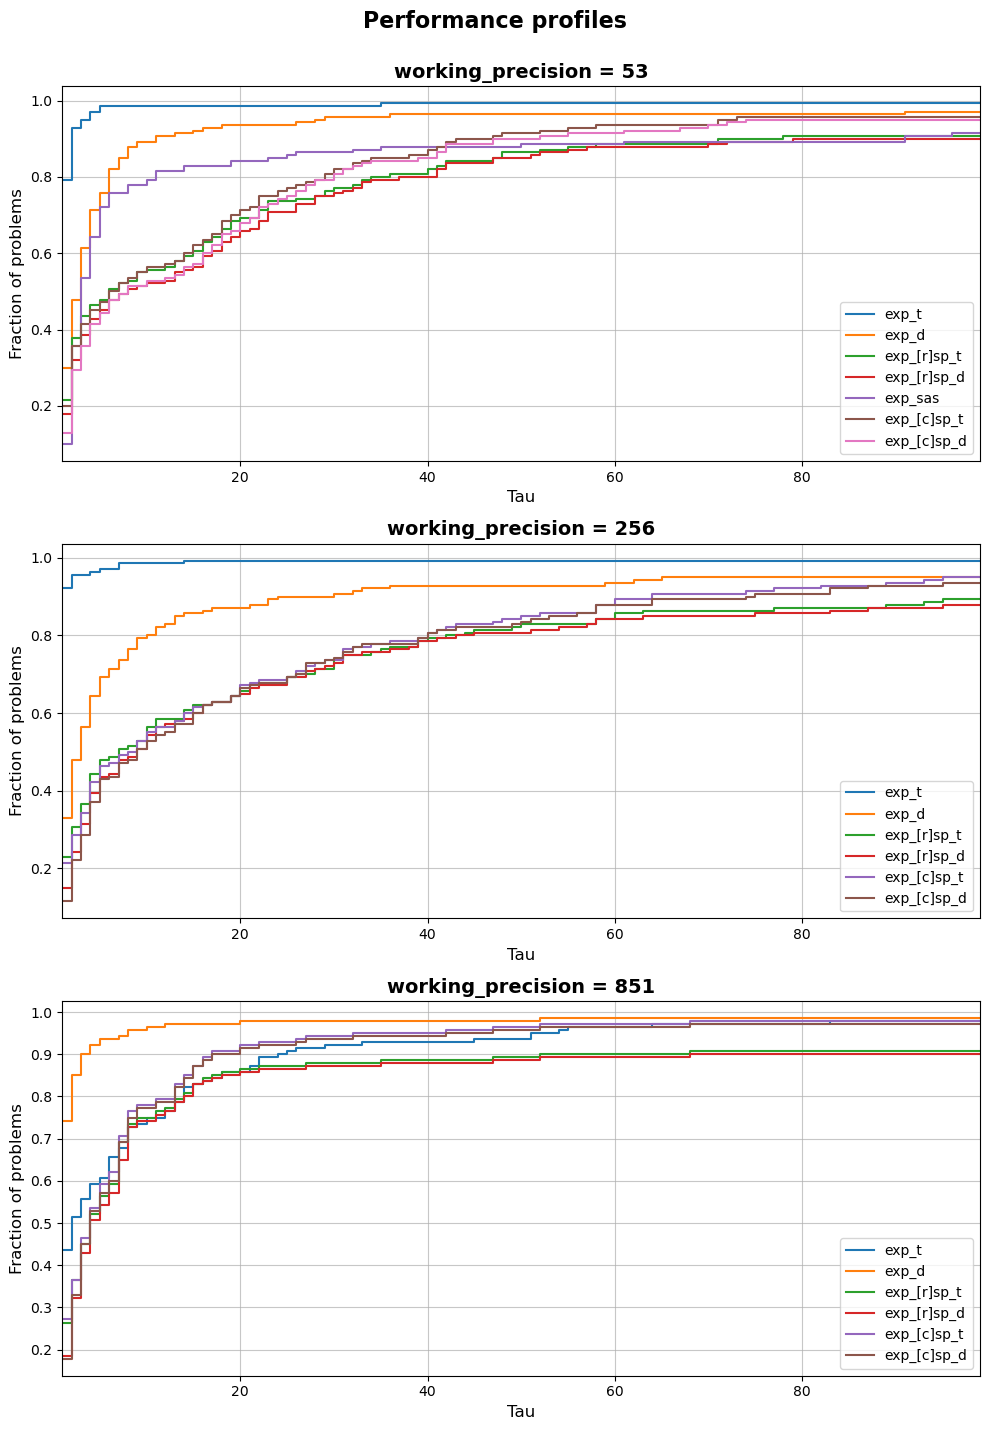

In [42]:
fig, axs = plt.subplots(len(WRK_PRECS), 1, figsize=(10, 5 * len(WRK_PRECS)))
fig.suptitle("Performance profiles", fontsize=16, fontweight="bold")

for i, prec in enumerate(WRK_PRECS):
    df_p_perfprof = df[df["precision"] == prec].copy()
    df_p_perfprof = df_p_perfprof.dropna(subset=["cond_expA_F"])    # Nota 1

    # avendo droppato i NaN, è sempre True (Nota 2)
    df_p_perfprof["feas"] = df_p_perfprof["cond_expA_F"].map(lambda x: not(pd.isna(x)))

    # Nota 3
    cols_toCopy = ["kind", "n", "eltype", "ishermitian", "approximant", "nrm1_Ytrue", "Ytrue_method", "cond_expA_F", "condA_1", "condA_2", "precision"]
    data = df_p_perfprof.loc[
        (df_p_perfprof["eltype"].isin(["ComplexF64", "Complex{BigFloat}"]))
        & ~(df_p_perfprof["approximant"] == "scaling_and_squaring"),
        cols_toCopy
    ].drop_duplicates()
    data.loc[data.index, "feas"] = False
    data.loc[data.index, "algorithm"] = "realschur"
    data.loc[data.index, df_p_perfprof.columns.difference(data.columns)] = pd.NA
    data.loc[data.index, "rel_err_F"] = np.inf
    df_p_perfprof = pd.concat([df_p_perfprof, data], ignore_index=True)

    taus, solver_vals, solvers, transformed_data = optperfprofpy.calc_perprof(
        df=df_p_perfprof,                           # dataframe
        problem_def=["kind", "n"],                  # problem definition
        perf_meas=["rel_err_F"],                    # performance measure
        solver_char=["algorithm", "approximant"],   # solver characterization
        #inv_perf_meas=True
        tau_val = list(range(1,100)),               # valori di tau in input (Nota 4)
        safe_divisions=True                     # trasforma i 0/0 in 1, e altro (Nota 4)
    )

    axs[i].set_title(f"working_precision = {prec}", fontsize=14, fontweight="bold")
    produce_perfprof(axs[i], taus, solver_vals, solvers, unify_schur=None)

plt.tight_layout(rect=[0, 0.03, 1, 0.98])
plt.show()    


Higham e Fasi però mostrano solo un algoritmo Schur-Padé. Guardando il loro codice, solo l'opzione `complexschur` è messa a confronto con le altre. In effetti, per ciascun'opzione di `approximant` i performance profiles delle due versioni si somigliano molto. Inoltre, come già detto, `realschur` non è presente per tutte le matrici.

Però boh oramai li ho eseguiti entrambi... Produciamo un plot in cui prendiamo la media tra la frazione di `realschur` e quella di `complexschur`!

In [43]:
solvers

array(['complexschur_diagonalcheap', 'complexschur_taylor',
       'realschur_diagonalcheap', 'realschur_taylor',
       'transfree_diagonalcheap', 'transfree_taylor'], dtype=object)

In [44]:
sorted(solvers)

['complexschur_diagonalcheap',
 'complexschur_taylor',
 'realschur_diagonalcheap',
 'realschur_taylor',
 'transfree_diagonalcheap',
 'transfree_taylor']

/tmp/ipykernel_5216/2824808383.py:22: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_p_perfprof = pd.concat([df_p_perfprof, data], ignore_index=True)


Number of problems per solver:  140


/media/andrea/Windows/Users/marin/Documents/Programmazione/Tesi-project/Dati_benchmarks_et_al/optperfprofpy.py:195: UserWarning: Solvers do not solve 100% of problems. Total amount of problems solved: 191.42857142857142
  warnings.warn('Solvers do not solve 100% of problems. '
/tmp/ipykernel_5216/2824808383.py:22: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_p_perfprof = pd.concat([df_p_perfprof, data], ignore_index=True)


Number of problems per solver:  140


/media/andrea/Windows/Users/marin/Documents/Programmazione/Tesi-project/Dati_benchmarks_et_al/optperfprofpy.py:195: UserWarning: Solvers do not solve 100% of problems. Total amount of problems solved: 195.7142857142857
  warnings.warn('Solvers do not solve 100% of problems. '
/tmp/ipykernel_5216/2824808383.py:22: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_p_perfprof = pd.concat([df_p_perfprof, data], ignore_index=True)


Number of problems per solver:  140


/media/andrea/Windows/Users/marin/Documents/Programmazione/Tesi-project/Dati_benchmarks_et_al/optperfprofpy.py:195: UserWarning: Solvers do not solve 100% of problems. Total amount of problems solved: 207.85714285714283
  warnings.warn('Solvers do not solve 100% of problems. '


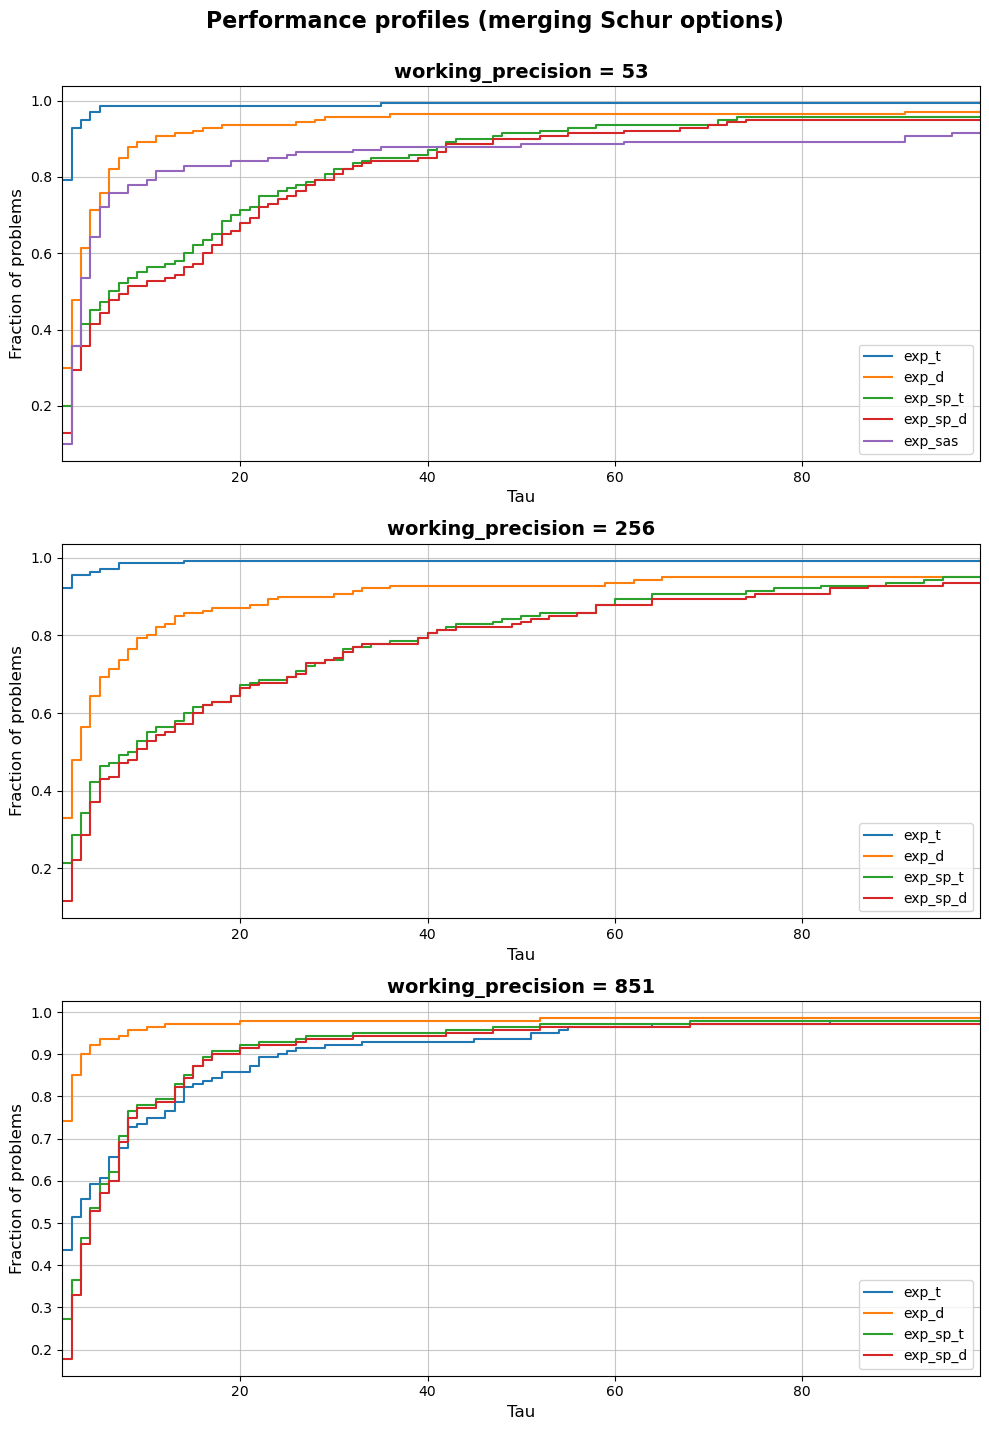

In [45]:
fig, axs = plt.subplots(len(WRK_PRECS), 1, figsize=(10, 5 * len(WRK_PRECS)))
fig.suptitle("Performance profiles (merging Schur options)", fontsize=16, fontweight="bold")

for i, prec in enumerate(WRK_PRECS):
    df_p_perfprof = df[df["precision"] == prec].copy()
    df_p_perfprof = df_p_perfprof.dropna(subset=["cond_expA_F"])    # Nota 1

    # avendo droppato i NaN, è sempre True (Nota 2)
    df_p_perfprof["feas"] = df_p_perfprof["cond_expA_F"].map(lambda x: not(pd.isna(x)))

    # Nota 3
    cols_toCopy = ["kind", "n", "eltype", "ishermitian", "approximant", "nrm1_Ytrue", "Ytrue_method", "cond_expA_F", "condA_1", "condA_2", "precision"]
    data = df_p_perfprof.loc[
            (df_p_perfprof["eltype"].isin(["ComplexF64", "Complex{BigFloat}"]))
            & ~(df_p_perfprof["approximant"] == "scaling_and_squaring"),
            cols_toCopy
        ].drop_duplicates()
    data.loc[data.index, "feas"] = False
    data.loc[data.index, "algorithm"] = "realschur"
    data.loc[data.index, df_p_perfprof.columns.difference(data.columns)] = pd.NA
    data.loc[data.index, "rel_err_F"] = np.inf
    df_p_perfprof = pd.concat([df_p_perfprof, data], ignore_index=True)

    taus, solver_vals, solvers, transformed_data = optperfprofpy.calc_perprof(
        df=df_p_perfprof,                           # dataframe
        problem_def=["kind", "n"],                  # problem definition
        perf_meas=["rel_err_F"],                    # performance measure
        solver_char=["algorithm", "approximant"],   # solver characterization
        #inv_perf_meas=True
        tau_val = list(range(1,100)),               # valori di tau in input (Nota 4)
        safe_divisions=True                     # trasforma i 0/0 in 1 (Nota 4)
    )

    axs[i].set_title(f"working_precision = {prec}", fontsize=14, fontweight="bold")
    produce_perfprof(axs[i], taus, solver_vals, solvers, unify_schur="complex")

plt.tight_layout(rect=[0, 0.03, 1, 0.98])
plt.show()    

Facciamone una versione per la tesi. Say cheese!

/tmp/ipykernel_5216/2202117056.py:22: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_p_perfprof = pd.concat([df_p_perfprof, data], ignore_index=True)


Number of problems per solver:  140


/media/andrea/Windows/Users/marin/Documents/Programmazione/Tesi-project/Dati_benchmarks_et_al/optperfprofpy.py:195: UserWarning: Solvers do not solve 100% of problems. Total amount of problems solved: 191.42857142857142
  warnings.warn('Solvers do not solve 100% of problems. '
/tmp/ipykernel_5216/2202117056.py:22: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_p_perfprof = pd.concat([df_p_perfprof, data], ignore_index=True)


Number of problems per solver:  140


/media/andrea/Windows/Users/marin/Documents/Programmazione/Tesi-project/Dati_benchmarks_et_al/optperfprofpy.py:195: UserWarning: Solvers do not solve 100% of problems. Total amount of problems solved: 195.7142857142857
  warnings.warn('Solvers do not solve 100% of problems. '
/tmp/ipykernel_5216/2202117056.py:22: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_p_perfprof = pd.concat([df_p_perfprof, data], ignore_index=True)


Number of problems per solver:  140


/media/andrea/Windows/Users/marin/Documents/Programmazione/Tesi-project/Dati_benchmarks_et_al/optperfprofpy.py:195: UserWarning: Solvers do not solve 100% of problems. Total amount of problems solved: 207.85714285714283
  warnings.warn('Solvers do not solve 100% of problems. '


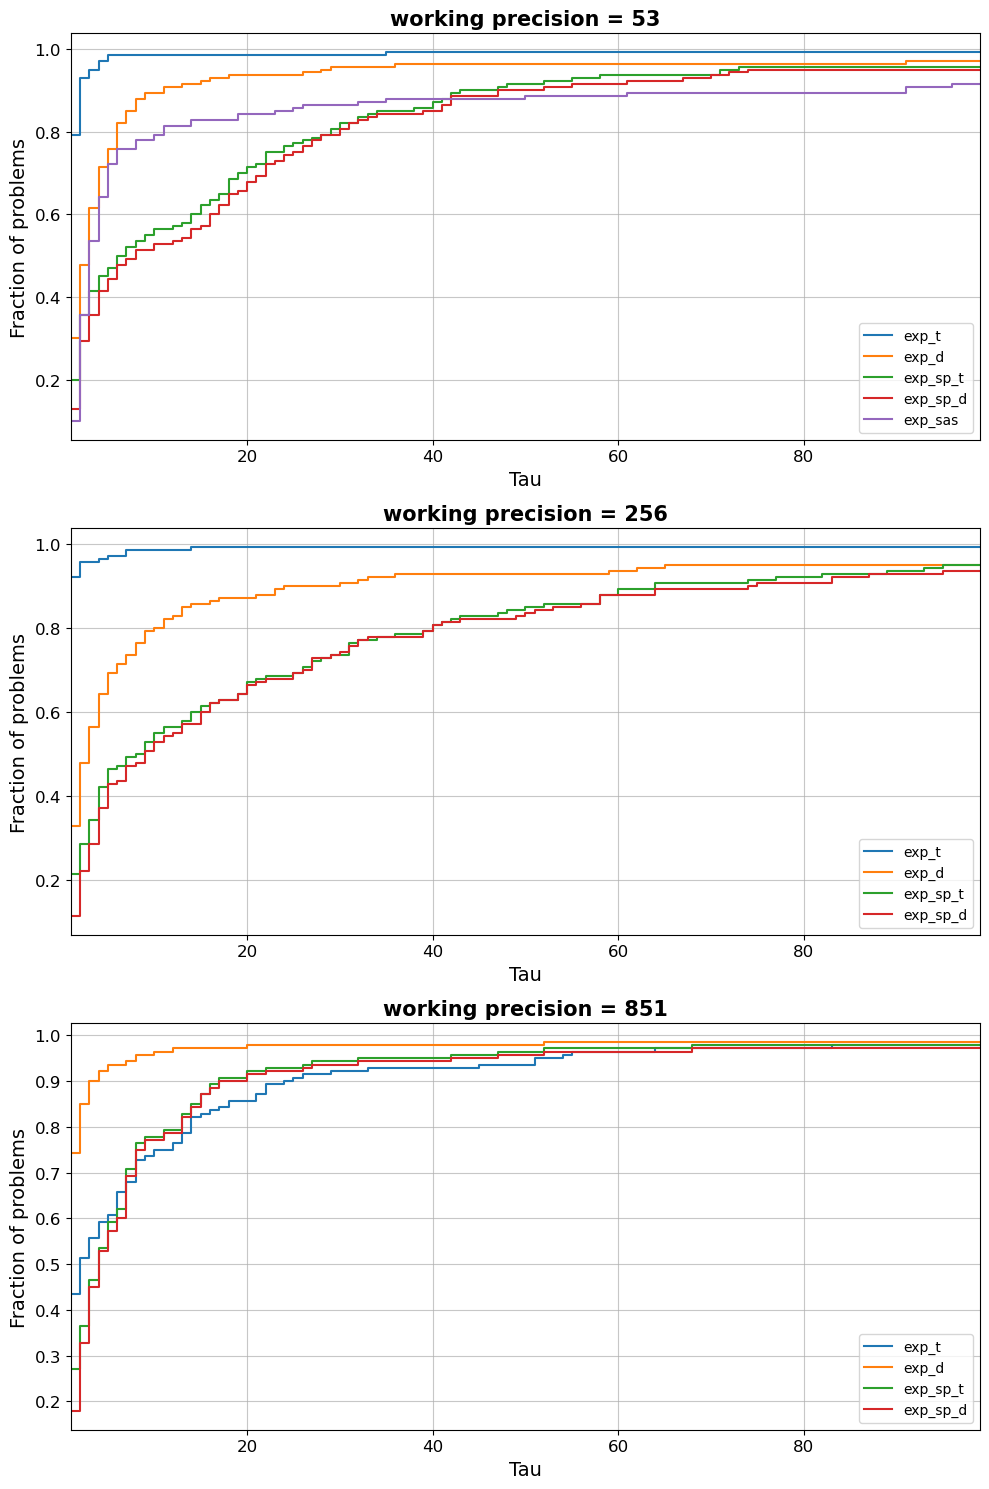

In [46]:
fig, axs = plt.subplots(len(WRK_PRECS), 1, figsize=(10, 5 * len(WRK_PRECS)))
#fig.suptitle("Performance profiles (merging Schur options)", fontsize=16, fontweight="bold")

for i, prec in enumerate(WRK_PRECS):
    df_p_perfprof = df[df["precision"] == prec].copy()
    df_p_perfprof = df_p_perfprof.dropna(subset=["cond_expA_F"])    # Nota 1

    # avendo droppato i NaN, è sempre True (Nota 2)
    df_p_perfprof["feas"] = df_p_perfprof["cond_expA_F"].map(lambda x: not(pd.isna(x)))

    # Nota 3
    cols_toCopy = ["kind", "n", "eltype", "ishermitian", "approximant", "nrm1_Ytrue", "Ytrue_method", "cond_expA_F", "condA_1", "condA_2", "precision"]
    data = df_p_perfprof.loc[
            (df_p_perfprof["eltype"].isin(["ComplexF64", "Complex{BigFloat}"]))
            & ~(df_p_perfprof["approximant"] == "scaling_and_squaring"),
            cols_toCopy
        ].drop_duplicates()
    data.loc[data.index, "feas"] = False
    data.loc[data.index, "algorithm"] = "realschur"
    data.loc[data.index, df_p_perfprof.columns.difference(data.columns)] = pd.NA
    data.loc[data.index, "rel_err_F"] = np.inf
    df_p_perfprof = pd.concat([df_p_perfprof, data], ignore_index=True)

    taus, solver_vals, solvers, transformed_data = optperfprofpy.calc_perprof(
        df=df_p_perfprof,                           # dataframe
        problem_def=["kind", "n"],                  # problem definition
        perf_meas=["rel_err_F"],                    # performance measure
        solver_char=["algorithm", "approximant"],   # solver characterization
        #inv_perf_meas=True
        tau_val = list(range(1,100)),               # valori di tau in input (Nota 4)
        safe_divisions=True                     # trasforma i 0/0 in 1 (Nota 4)
    )

    axs[i].set_title(f"working precision = {prec}", fontsize=15, fontweight="bold")
    produce_perfprof(axs[i], taus, solver_vals, solvers, unify_schur="complex")
    axs[i].tick_params(axis="both", labelsize=12)
    axs[i].set_xlabel("Tau", fontsize=14)
    axs[i].set_ylabel("Fraction of problems", fontsize=14)

plt.tight_layout()
plt.show()    

##### Esperimenti con i performance profiles

Sposto qui le prove, le evidenze, che ho fatto con i perfprof.

In [47]:
df_p_perfprof = df[df["precision"] == 851].copy()
df_p_perfprof = df_p_perfprof.dropna(subset=["cond_expA_F"])    # Nota 1

# avendo droppato i NaN, è sempre True (Nota 2)
df_p_perfprof["feas"] = df_p_perfprof["cond_expA_F"].map(lambda x: not(pd.isna(x)))

# Nota 3
cols_toCopy = ["kind", "n", "eltype", "ishermitian", "approximant", "nrm1_Ytrue", "Ytrue_method", "cond_expA_F", "condA_1", "condA_2", "precision"]
data = df_p_perfprof.loc[
            (df_p_perfprof["eltype"].isin(["ComplexF64", "Complex{BigFloat}"])),
            cols_toCopy
        ].drop_duplicates() # prendiamo i samples complessi
data.loc[data.index, "feas"] = False
data.loc[data.index, "algorithm"] = "realschur"
data.loc[data.index, df_p_perfprof.columns.difference(data.columns)] = pd.NA
data.loc[data.index, "rel_err_F"] = np.inf
df_p_perfprof = pd.concat([df_p_perfprof, data], ignore_index=True)

taus, solver_vals, solvers, transformed_data = optperfprofpy.calc_perprof(
    df=df_p_perfprof,                           # dataframe
    problem_def=["kind", "n"],                  # problem definition
    perf_meas=["rel_err_F"],                    # performance measure
    solver_char=["algorithm", "approximant"],   # solver characterization
    #inv_perf_meas=True
    #tau_val = list(range(1,100)),               # valori di tau in input (Nota 4)
    safe_divisions=True                     # trasforma i 0/0 in 1, e altro (Nota 4)
)

/tmp/ipykernel_5216/4266853393.py:17: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_p_perfprof = pd.concat([df_p_perfprof, data], ignore_index=True)


Number of problems per solver:  140


/media/andrea/Windows/Users/marin/Documents/Programmazione/Tesi-project/Dati_benchmarks_et_al/optperfprofpy.py:195: UserWarning: Solvers do not solve 100% of problems. Total amount of problems solved: 207.85714285714283
  warnings.warn('Solvers do not solve 100% of problems. '


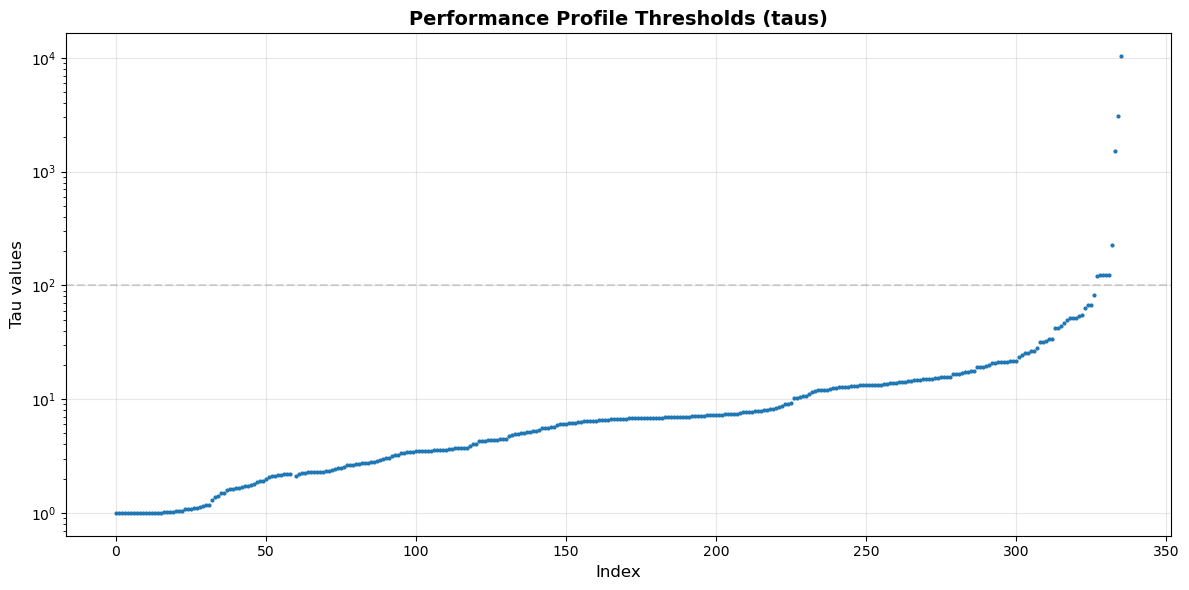

In [48]:
plt.figure(figsize=(12, 6))
plt.plot(taus, marker='o', linestyle='', markersize=2)
plt.axhline(100, color="grey", linestyle="--", alpha=0.3)
plt.xlabel('Index', fontsize=12)
plt.ylabel('Tau values', fontsize=12)
plt.title('Performance Profile Thresholds (taus)', fontsize=14, fontweight='bold')
plt.yscale('log')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [49]:
print(f"Inf appartiene a tau = {np.inf in taus}")
print(f"NaN appartiene a taus = {any([np.isnan(t) for t in taus])}")

taus_stripped = taus[np.isfinite(np.array(taus, dtype=float))]
print(f"Ci sono {np.sum(taus_stripped > 1e2)} valori di tau maggiori di 100")

Inf appartiene a tau = True
NaN appartiene a taus = True
Ci sono 9 valori di tau maggiori di 100


### Parametri scelti, doppia precisione

Vediamo quali valori di $s$ e $m$ vengono scelti dal nostro algoritmo, quando viene eseguito in doppia precisione. Confrontiamoli con quelli scelti dall'`exp` base di Julia

In [3]:
df_ms = pd.read_csv("ms-bench-v0.1.5alpha-08_07.csv")

In [4]:
print(f"df_ms.shape = {df_ms.shape}")

df_ms.shape = (842, 15)


In [5]:
df_ms.head()

,kind,n,eltype,ishermitian,approximant,algorithm,m,s,delta,psi,cond_q,epsilon,m_base,s_base,precision
0,rand_8,8,Float64,False,diagonalcheap,transfree,13.0,0.0,4.137105e-16,80.906243,23.980249,2.220446e-16,13.0,0.0,53
1,rand_8,8,Float64,False,diagonalcheap,complexschur,13.0,0.0,1.727864e-16,63.207865,13.821267,2.220446e-16,13.0,0.0,53
2,rand_8,8,Float64,False,diagonalcheap,realschur,13.0,0.0,1.727864e-16,63.207865,15.003918,2.220446e-16,13.0,0.0,53
3,rand_8,8,Float64,False,taylor,transfree,25.0,1.0,1.734723e-18,8.330209,1.000000,2.220446e-16,13.0,0.0,53
4,rand_8,8,Float64,False,taylor,complexschur,25.0,1.0,0.000000e+00,6.707511,1.000000,2.220446e-16,13.0,0.0,53


In [16]:
df_ms.columns

Index(['kind', 'n', 'eltype', 'ishermitian', 'approximant', 'algorithm', 'm',
       's', 'delta', 'psi', 'cond_q', 'epsilon', 'm_base', 's_base',
       'precision'],
      dtype='object')

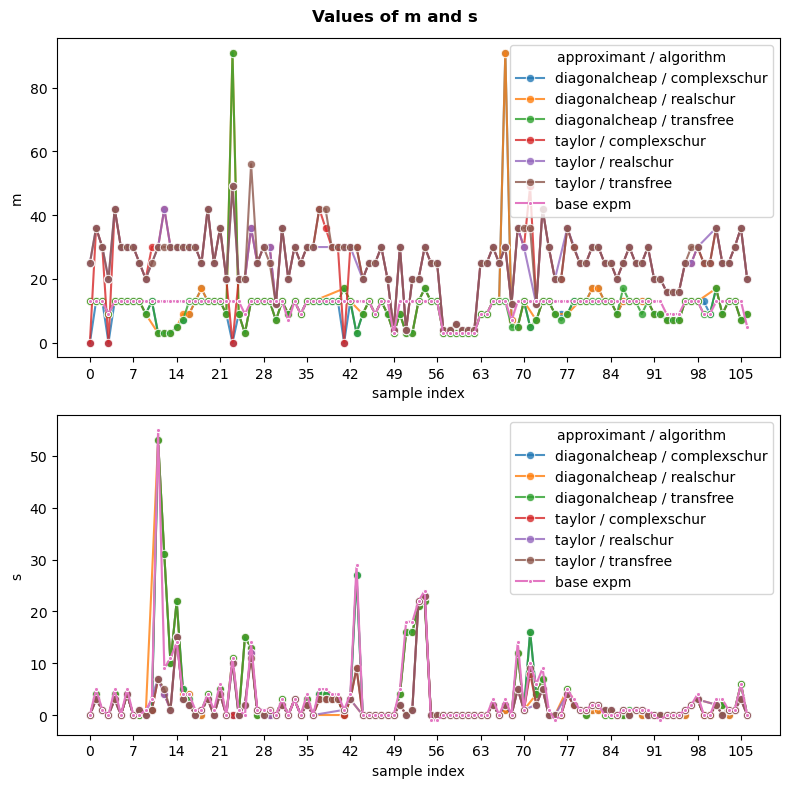

In [ ]:
fig, axs = plt.subplots(2,1, figsize=(8,8))
plt.suptitle("Values of m and s", fontweight="bold")

# WIP: usa solo diagonalcheap
df_m = df_ms.loc[~df_ms["ishermitian"]].copy()
df_m["solver"] = df_m["approximant"].astype(str) + " / " + df_m["algorithm"].astype(str)
df_m["sample"] = df_m["kind"].astype(str) + " (n=" + df_m["n"].astype(str) + ")"

# m
sns.lineplot(
    data=df_m.sort_values(["solver", "kind", "n"]),
    x="sample", y="m",
    hue="solver",
    marker="o", alpha=0.8,
    sort=False,
    ax=axs[0],
)

sns.lineplot(
    data=df_m.sort_values(["solver", "kind", "n"]),
    x="sample", y="m_base",
    label="base expm",
    marker=".",
    sort=False,
    ax=axs[0],
)

# s
sns.lineplot(
    data=df_m.sort_values(["solver", "kind", "n"]),
    x="sample", y="s",
    hue="solver",
    marker="o", alpha=0.8,
    sort=False,
    ax=axs[1],
)

sns.lineplot(
    data=df_m.sort_values(["solver", "kind", "n"]),
    x="sample", y="s_base",
    label="base expm",
    marker=".",
    sort=False,
    ax=axs[1],
)

for i in [0,1]:
    axs[i].set_xlabel("sample index")
    xticks = axs[i].get_xticks()
    step = max(1, len(xticks) // 15)  # show ~15 ticks
    sel_ticks = xticks[::step]
    axs[i].set_xticks(sel_ticks)
    axs[i].set_xticklabels([str(int(t)) for t in sel_ticks], rotation=0)
    axs[i].legend(title="approximant / algorithm")


plt.tight_layout()
plt.show()